In [45]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import yaml
import os
import copy
import glob
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
import pandas as pd
import shutil
from scipy.optimize import minimize
from scipy.stats import norm
import seaborn as sns
from numpy.fft import rfft, rfftfreq


In [22]:
def load_stellar_grid(filename):
    """Loads all physically valid stellar states from the HDF5 grid."""
    print("Loading stellar grid...")
    valid_stars = []
    
    def get_data(obj, field):
        if isinstance(obj, h5py.Dataset):
            return obj[field]
        else:
            return obj[field][:]

    with h5py.File(filename, 'r') as f:
        for key in f.keys():
            try:
                group = f[key]
                g_data = group['global']
                
                teffs = get_data(g_data, 'teff')
                loggs = get_data(g_data, 'logg')
                
                try:
                    mass = float(group['parameters/mass0'][()])
                except:
                    mass = float(get_data(g_data, 'mass')[0])
                
                # Add every evolutionary stage along this track
                for i in range(len(teffs)):
                    valid_stars.append({
                        "mass": mass,
                        "teff": float(teffs[i]),
                        "logg": float(loggs[i])
                    })
            except Exception:
                continue
                
    print(f"Loaded {len(valid_stars)} valid stellar states.")
    return valid_stars

In [10]:
import os
import copy
import yaml
import numpy as np
import pandas as pd

# --- Setup ---
with open("../psls-1.9/psls.yaml", "r") as file:
    base_config = yaml.safe_load(file)

stellar_grid = load_stellar_grid("../psls-1.9/grid_plato.hdf5")
os.makedirs("configs", exist_ok=True)
metadata_records = []

# --- Config ---
num_systems = 1_000
anomaly_classes = np.repeat([0, 1, 2, 3], num_systems // 4)
np.random.shuffle(anomaly_classes)

for i, anomaly_type in enumerate(anomaly_classes):
    system_config = copy.deepcopy(base_config)
    seed = int(np.random.randint(1000000, 9999999))
    system_config['Observation']['MasterSeed'] = seed

    # Gaps: always off — applied in postprocessing
    system_config['Observation']['Gaps']['Enable'] = 0

    star = np.random.choice(stellar_grid)
    system_config['Star']['Teff'] = star["teff"]
    system_config['Star']['Logg'] = star["logg"]

    has_flares  = anomaly_type in (1, 3)
    has_transit = anomaly_type in (2, 3)

    # --- Flares ---
    system_config['Activity']['Flare']['Enable'] = int(has_flares)
    flare_amplitude = 0
    if has_flares:
        flare_amplitude = float(np.exp(np.random.uniform(np.log(500), np.log(20000))))
        mean_dur = float(np.random.uniform(0.01, 0.1))
        system_config['Activity']['Flare']['Amplitude']          = flare_amplitude
        system_config['Activity']['Flare']['MeanPeriod']         = float(np.random.uniform(1.0, 15.0))
        system_config['Activity']['Flare']['MeanDuration']       = mean_dur
        system_config['Activity']['Flare']['DurationDispersion'] = mean_dur * 0.2
        system_config['Activity']['Flare']['UpDown']             = float(np.random.uniform(0.05, 0.3))

    # --- Transits ---
    system_config['Transit']['Enable'] = int(has_transit)
    transit_period = 0
    radius_earth   = 0
    if has_transit:
        period_days   = np.exp(np.random.uniform(np.log(2.0), np.log(100.0)))
        period_years  = period_days / 365.25
        a_au          = (star["mass"] * (period_years ** 2)) ** (1 / 3)
        radius_earth  = np.random.lognormal(mean=np.log(1.7), sigma=1.0)
        transit_period = float(period_days)
        system_config['Transit']['OrbitalPeriod']        = transit_period
        system_config['Transit']['PlanetSemiMajorAxis']  = float(a_au)
        system_config['Transit']['PlanetRadius']         = float(max(0.1, radius_earth) / 11.20)

    #randomy pick a drift level for the systematics
    drift_levels = ['low', 'medium', 'high', 'max']

    drift = str(np.random.choice(drift_levels))
    print(f"System {1000+i:04d}: Drift level set to '{drift}'")
    system_config['Instrument']['Systematics']['DriftLevel'] = drift

    filename = f"configs/sys_{1000+i:04d}.yaml"
    with open(filename, "w") as out_file:
        yaml.safe_dump(system_config, out_file, default_flow_style=False)

    metadata_records.append({
        "system_id":           f"sys_{1000+i:04d}",
        "master_seed":         seed,
        "anomaly_class":       anomaly_type,
        "label_has_flares":    int(has_flares),
        "label_has_transit":   int(has_transit),
        "star_mass":           star["mass"],
        "star_teff":           star["teff"],
        "star_logg":           star["logg"],
        "flare_amplitude":     flare_amplitude,
        "transit_period":      transit_period,
        "transit_radius_earth": radius_earth,
        "drift": drift
    })

df_metadata = pd.DataFrame(metadata_records)
df_metadata.to_csv("paired_simulation_labels_drift.csv", index=False)
print(f"Done. Generated {num_systems} configs.")

Loading stellar grid...


/var/folders/dt/hdl85s4s5jng99gtl5y_bxnr0000gn/T/ipykernel_94131/1803630385.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(group['parameters/mass0'][()])


Loaded 111289 valid stellar states.
System 1000: Drift level set to 'max'
System 1001: Drift level set to 'high'
System 1002: Drift level set to 'high'
System 1003: Drift level set to 'high'
System 1004: Drift level set to 'max'
System 1005: Drift level set to 'low'
System 1006: Drift level set to 'low'
System 1007: Drift level set to 'medium'
System 1008: Drift level set to 'medium'
System 1009: Drift level set to 'max'
System 1010: Drift level set to 'medium'
System 1011: Drift level set to 'medium'
System 1012: Drift level set to 'low'
System 1013: Drift level set to 'max'
System 1014: Drift level set to 'medium'
System 1015: Drift level set to 'low'
System 1016: Drift level set to 'high'
System 1017: Drift level set to 'medium'
System 1018: Drift level set to 'high'
System 1019: Drift level set to 'high'
System 1020: Drift level set to 'low'
System 1021: Drift level set to 'medium'
System 1022: Drift level set to 'low'
System 1023: Drift level set to 'low'
System 1024: Drift level 

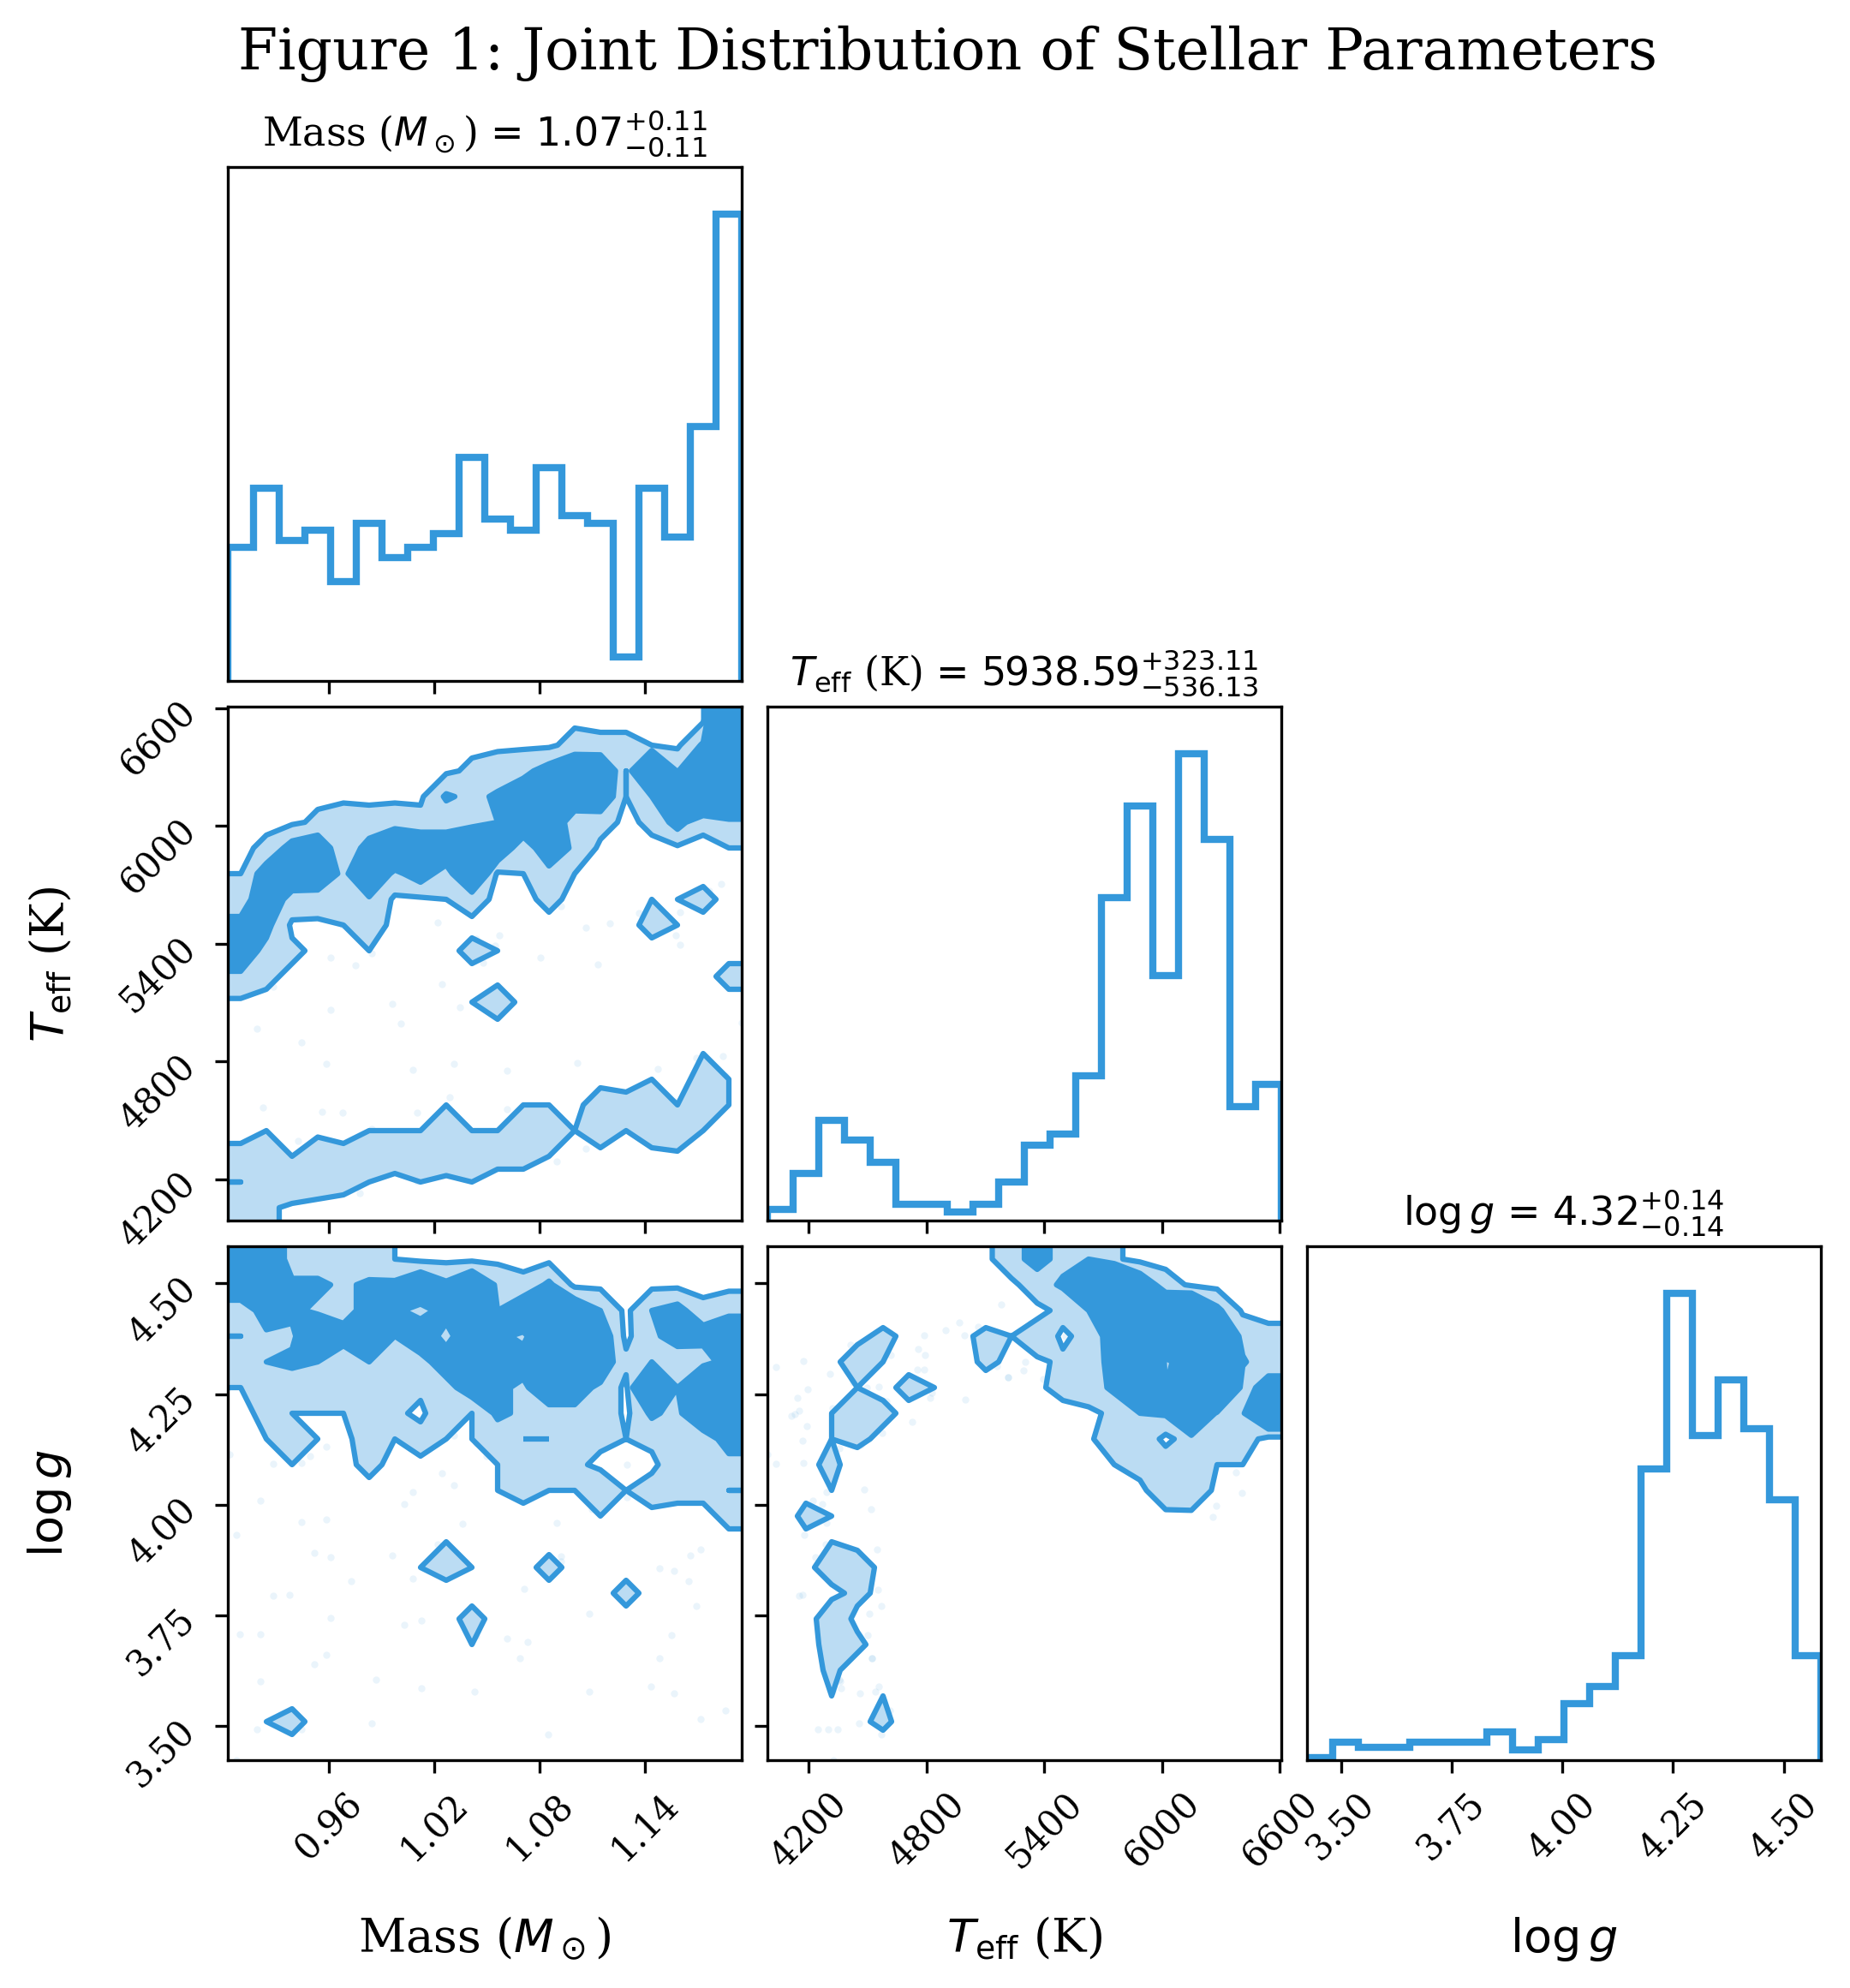

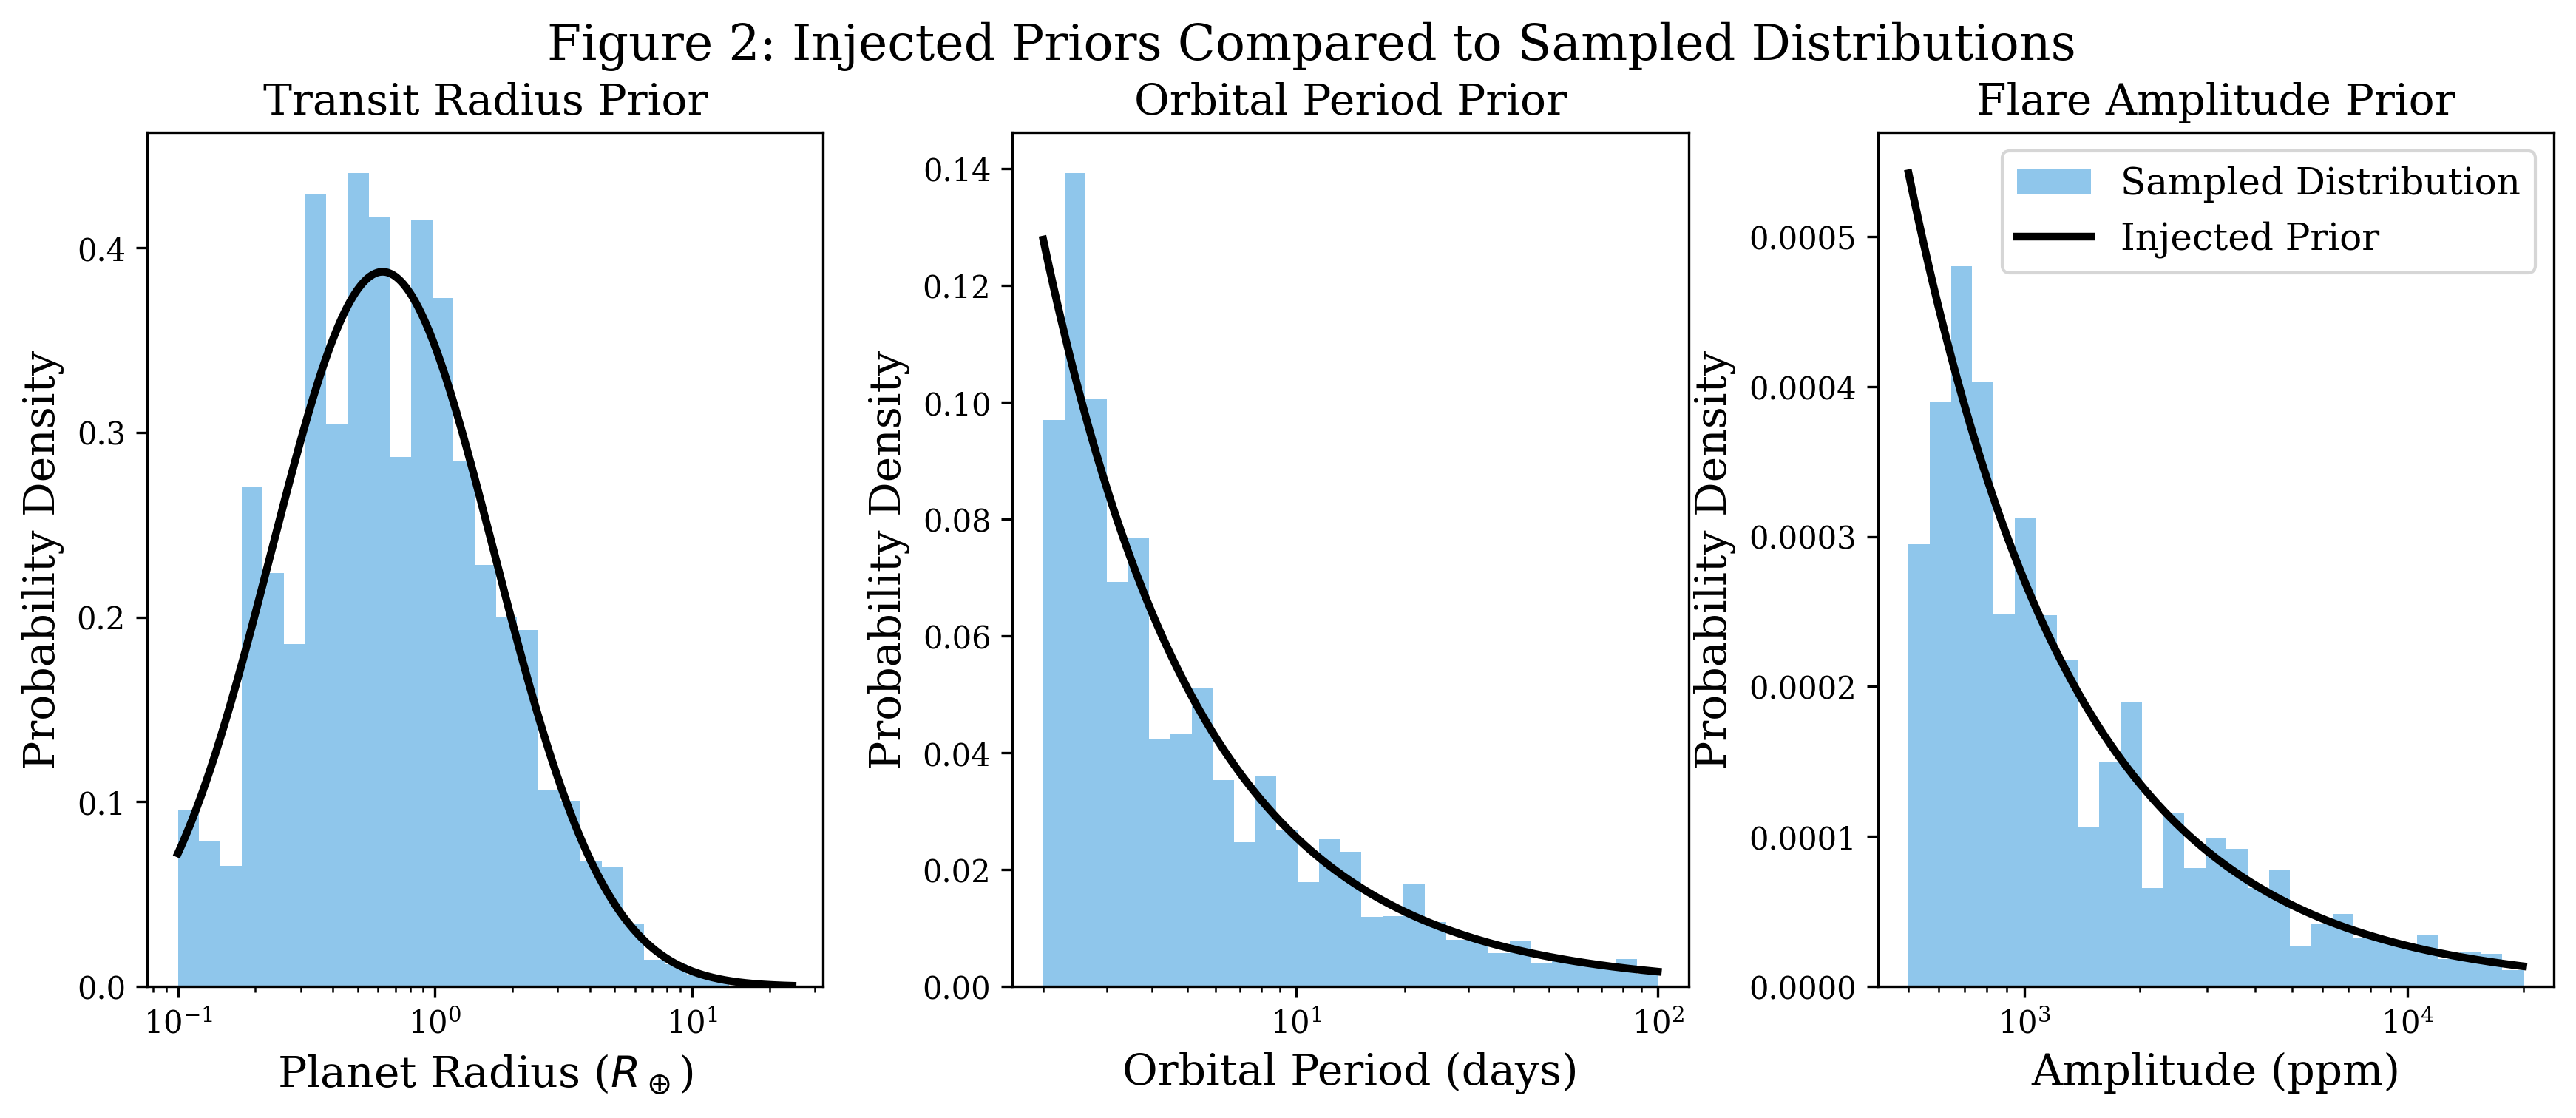

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy.stats import lognorm

# ==========================================
# 1. Setup Paper-Ready Matplotlib Style
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,
    "figure.dpi": 300
})

theme_color = "#3498db"

# ==========================================
# Load Metadata
# ==========================================
df = pd.read_csv("paired_simulation_labels.csv")

# ==========================================
# FIGURE 1: Stellar Parameter Corner Plot
# ==========================================
stellar_data = df[['star_mass', 'star_teff', 'star_logg']].dropna().values

fig_corner = corner.corner(
    stellar_data,
    labels=[r"Mass ($M_\odot$)", r"$T_{\rm eff}$ (K)", r"$\log g$"],
    color=theme_color,
    show_titles=True,
    title_kwargs={"fontsize": 11},
    hist_kwargs={"linewidth": 2},
    label_kwargs={"fontsize": 13},
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.68, 0.95)
)

fig_corner.suptitle(
    "Figure 1: Joint Distribution of Stellar Parameters",
    y=1.02,
    fontsize=16
)

plt.savefig("thesis_stellar_corner.pdf", bbox_inches='tight')
plt.show()

# ==========================================
# FIGURE 2: Injected Priors vs Sampled Data
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.subplots_adjust(hspace=0.35, wspace=0.28)

flares = df[df['flare_amplitude'] > 0]
transits = df[df['transit_period'] > 0]

# ==========================================
# A. Transit Radius (Lognormal)
# ==========================================
ax = axes[0]

data_rad = transits['transit_radius_earth']

bins_rad = np.logspace(
    np.log10(0.1),
    np.log10(data_rad.max()),
    30
)

ax.hist(
    data_rad,
    bins=bins_rad,
    density=True,
    color=theme_color,
    alpha=0.55
)

# Analytical prior
x_rad = np.logspace(np.log10(0.1), np.log10(data_rad.max()), 500)

pdf_rad = lognorm.pdf(
    x_rad,
    s=1.0,
    scale=np.exp(np.log(1.7))
)

ax.plot(
    x_rad,
    pdf_rad,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Transit Radius Prior')
ax.set_xlabel(r'Planet Radius ($R_\oplus$)')
ax.set_ylabel('Probability Density')

# ==========================================
# B. Transit Period (Log-Uniform)
# ==========================================
ax = axes[1]

data_per = transits['transit_period']

bins_per = np.logspace(np.log10(2.0), np.log10(100.0), 30)

ax.hist(
    data_per,
    bins=bins_per,
    density=True,
    color=theme_color,
    alpha=0.55
)

x_per = np.logspace(np.log10(2.0), np.log10(100.0), 500)

# Proper log-uniform PDF in linear space
pdf_per = 1.0 / (
    x_per * (np.log(100.0) - np.log(2.0))
)

ax.plot(
    x_per,
    pdf_per,
    color='black',
    linewidth=2.5
)

ax.set_xscale('log')
ax.set_title('Orbital Period Prior')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Probability Density')

# ==========================================
# C. Flare Amplitude (Log-Uniform)
# ==========================================
ax = axes[2]

data_amp = flares['flare_amplitude']

bins_amp = np.logspace(np.log10(500), np.log10(20000), 30)

ax.hist(
    data_amp,
    bins=bins_amp,
    density=True,
    color=theme_color,
    alpha=0.55,
    label='Sampled Distribution'
)

x_amp = np.logspace(np.log10(500), np.log10(20000), 500)

pdf_amp = 1.0 / (
    x_amp * (np.log(20000) - np.log(500))
)

ax.plot(
    x_amp,
    pdf_amp,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Flare Amplitude Prior')
ax.set_xlabel('Amplitude (ppm)')
ax.set_ylabel('Probability Density')
ax.legend()


# ==========================================
# Final Formatting
# ==========================================
plt.suptitle(
    "Figure 2: Injected Priors Compared to Sampled Distributions",
    fontsize=16,
    y=0.98
)

plt.show()

In [11]:
!python -u run_simulations.py

Running 1000 systems sequentially...
Python: /Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/bin/python
PSLS:   /Users/isaacrosenberg/0. MASS Astrobiology/computational_astrobiology_belgrade/PlatoLightCurves/psls-1.9/psls.py

  ✓  sys_1000.yaml                                                              
  ✓  sys_1001.yaml                                                              
  ✓  sys_1002.yaml                                                              
  ✓  sys_1003.yaml                                                              
  ✓  sys_1004.yaml                                                              
  ✓  sys_1005.yaml                                                              
  ✓  sys_1006.yaml                                                              
  ✓  sys_1007.yaml                                                              
  ✓  sys_1008.yaml                                                              
  ✓  sys_1009.yaml                     

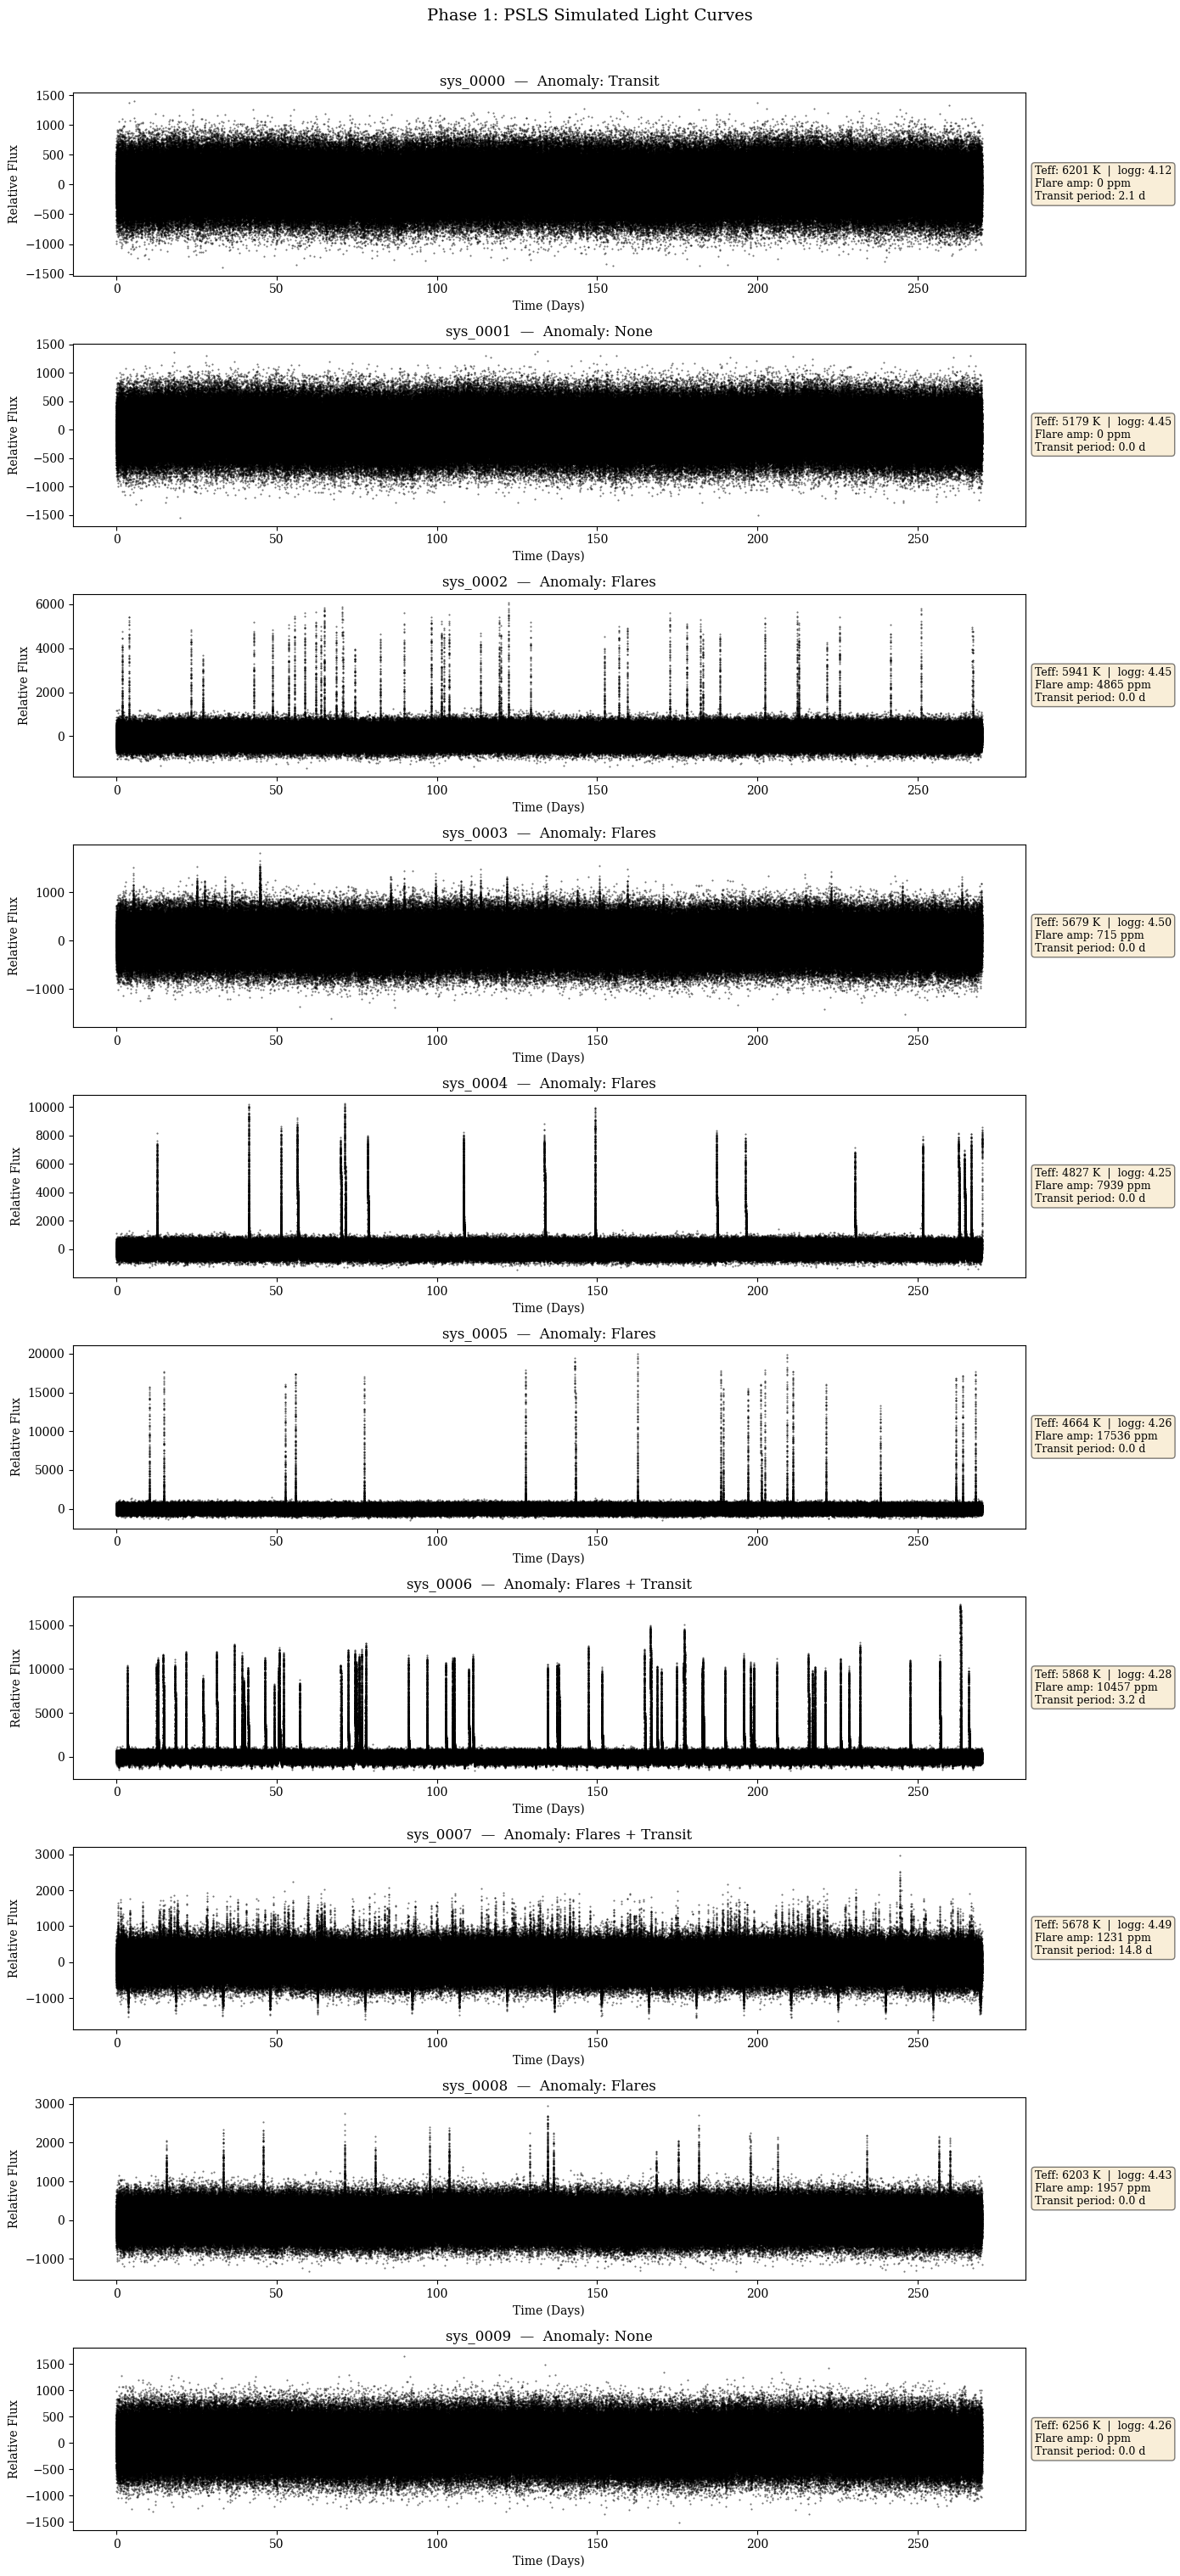

In [29]:
N = 10  # number of systems to plot

def load_lightcurve(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.hdf5")) + glob.glob(os.path.join(folder_path, "*.h5"))
    if files:
        with h5py.File(files[0], 'r') as f:
            try:
                return f['time'][:], f['flux'][:]
            except KeyError:
                keys = list(f.keys())
                return f[keys[0]][:], f[keys[1]][:]

    txt_files = glob.glob(os.path.join(folder_path, "*.dat"))
    if txt_files:
        data_rows = []
        with open(txt_files[0], 'r') as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                try:
                    data_rows.append([float(p) for p in parts])
                except ValueError:
                    continue
        data = np.array(data_rows)
        return data[:, 0], data[:, 1]

    return None, None

# --- Load metadata ---
df = pd.read_csv("paired_simulation_labels.csv")
test_systems = df.head(N)

anomaly_label = {0: "None", 1: "Flares", 2: "Transit", 3: "Flares + Transit"}

plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(14, 3 * N), sharex=False)
fig.subplots_adjust(hspace=0.5)

if N == 1:
    axes = [axes]

for i, (_, row) in enumerate(test_systems.iterrows()):
    sys_id = row['system_id']

    time, flux = load_lightcurve(f"outputs/{sys_id}/")

    if time is None:
        print(f"Could not find data for {sys_id}")
        continue

    ax = axes[i]
    ax.plot(time / 86400, flux, color='black', marker='.', markersize=1, linestyle='none', alpha=0.6)
    ax.set_title(f"{sys_id}  —  Anomaly: {anomaly_label[row['anomaly_class']]}")
    ax.set_ylabel("Relative Flux")
    ax.set_xlabel("Time (Days)")

    metadata_text = (
        f"Teff: {row['star_teff']:.0f} K  |  logg: {row['star_logg']:.2f}\n"
        f"Flare amp: {row['flare_amplitude']:.0f} ppm\n"
        f"Transit period: {row['transit_period']:.1f} d"
    )
    ax.text(1.01, 0.5, metadata_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Phase 1: PSLS Simulated Light Curves", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.3 Injecting Additional Anomaly Signals

These utilities add controlled, labeled post-processing anomalies to an already simulated PSLS light curve. The functions return both the modified flux and the injected signal in ppm, which makes them useful for supervised labels and recovery tests.

In [32]:
SECONDS_PER_DAY = 86400.0


def time_to_days(time):
    """Accept PSLS seconds or already-day arrays and return days."""
    time = np.asarray(time, dtype=float)
    if np.nanmax(time) > 1_000:
        return time / SECONDS_PER_DAY
    return time

def ppm_flux_scale(flux):
    """Return the additive scale that converts ppm signals to the flux units."""
    flux = np.asarray(flux, dtype=float)
    return 1.0 if np.nanmedian(np.abs(flux)) > 1_000 else 1e-6


def damped_sinusoid_signal(time, t0_day, amplitude_ppm=1_500.0, tau_days=2.0,
                            frequency_per_day=3.0, phase=0.0):
    r"""Damped sinusoid A exp(-dt/tau) sin(2 pi f dt + phase), in ppm."""
    days = time_to_days(time)
    dt = days - t0_day
    signal = np.zeros_like(days, dtype=float)
    active = dt >= 0
    signal[active] = (
        amplitude_ppm
        * np.exp(-dt[active] / tau_days)
        * np.sin(2.0 * np.pi * frequency_per_day * dt[active] + phase)
    )
    return signal

def quasi_periodic_oscillation_signal(time, t0_day, duration_days=8.0, amplitude_ppm=600.0,
                                       frequency_per_day=5.0, modulation_period_days=1.5,
                                       phase=0.0):
    """Finite-duration oscillation with a slowly modulated phase and amplitude."""
    days = time_to_days(time)
    dt = days - t0_day
    signal = np.zeros_like(days, dtype=float)
    active = (dt >= 0) & (dt <= duration_days)
    local_dt = dt[active]
    envelope = np.sin(np.pi * local_dt / duration_days) ** 2
    phase_mod = 0.25 * np.sin(2.0 * np.pi * local_dt / modulation_period_days)
    amp_mod = 1.0 + 0.35 * np.sin(2.0 * np.pi * local_dt / modulation_period_days + np.pi / 3.0)
    signal[active] = amplitude_ppm * envelope * amp_mod * np.sin(
        2.0 * np.pi * frequency_per_day * local_dt + phase_mod + phase
    )
    return signal

def unusual_transit_shape_signal(time, period_days, t0_day, depth_ppm=1_500.0,
                                  duration_days=0.35, asymmetry=0.35,
                                  shoulder_ppm=250.0):
    """Periodic asymmetric transit with a small pre-egress shoulder, in ppm."""
    days = time_to_days(time)
    phase = ((days - t0_day + 0.5 * period_days) % period_days) - 0.5 * period_days
    half_duration = 0.5 * duration_days
    signal = np.zeros_like(days, dtype=float)
    in_event = np.abs(phase) <= half_duration
    if not np.any(in_event):
        return signal

    x = phase[in_event] / half_duration
    ingress_width = max(0.1, 1.0 - asymmetry)
    egress_width = max(0.1, 1.0 + asymmetry)
    shape = np.where(
        x < 0,
        np.clip(1.0 + x / ingress_width, 0.0, 1.0),
        np.clip(1.0 - x / egress_width, 0.0, 1.0),
    )
    shoulder = shoulder_ppm * np.exp(-0.5 * ((x - 0.35) / 0.12) ** 2)
    signal[in_event] = -depth_ppm * shape + shoulder
    return signal

def inject_anomaly(time, flux, kind, rng=None, **params):
    """Inject one named anomaly and return flux_injected, signal_ppm, used_params."""
    rng = np.random.default_rng(rng)
    days = time_to_days(time)
    span = float(np.nanmax(days) - np.nanmin(days))
    start = float(np.nanmin(days) + 0.15 * span)
    stop = float(np.nanmax(days) - 0.15 * span)
    flux = np.asarray(flux, dtype=float)

    if kind == "damped_sinusoid":
        used = {
            "t0_day": float(params.get("t0_day", rng.uniform(start, stop))),
            "amplitude_ppm": float(params.get("amplitude_ppm", rng.uniform(500, 2_500))),
            "tau_days": float(params.get("tau_days", rng.uniform(0.5, 5.0))),
            "frequency_per_day": float(params.get("frequency_per_day", rng.uniform(0.5, 8.0))),
            "phase": float(params.get("phase", rng.uniform(0, 2 * np.pi))),
        }
        signal_ppm = damped_sinusoid_signal(time, **used)
    elif kind == "quasi_periodic_oscillation":
        used = {
            "t0_day": float(params.get("t0_day", rng.uniform(start, stop))),
            "duration_days": float(params.get("duration_days", rng.uniform(3.0, 15.0))),
            "amplitude_ppm": float(params.get("amplitude_ppm", rng.uniform(200, 1_200))),
            "frequency_per_day": float(params.get("frequency_per_day", rng.uniform(1.0, 10.0))),
            "modulation_period_days": float(params.get("modulation_period_days", rng.uniform(0.8, 3.0))),
            "phase": float(params.get("phase", rng.uniform(0, 2 * np.pi))),
        }
        signal_ppm = quasi_periodic_oscillation_signal(time, **used)
    elif kind == "unusual_transit_shape":
        used = {
            "period_days": float(params.get("period_days", rng.uniform(2.0, 30.0))),
            "t0_day": float(params.get("t0_day", rng.uniform(start, start + 2.0))),
            "depth_ppm": float(params.get("depth_ppm", rng.uniform(500, 3_000))),
            "duration_days": float(params.get("duration_days", rng.uniform(0.15, 0.7))),
            "asymmetry": float(params.get("asymmetry", rng.uniform(0.15, 0.65))),
            "shoulder_ppm": float(params.get("shoulder_ppm", rng.uniform(100, 500))),
        }
        signal_ppm = unusual_transit_shape_signal(time, **used)
    else:
        raise ValueError(
            "kind must be one of: stellar_flare, unusual_transit_shape, "
            "quasi_periodic_oscillation, damped_sinusoid"
        )

    injected_flux = flux + signal_ppm * ppm_flux_scale(flux)
    used["kind"] = kind
    return injected_flux, signal_ppm, used


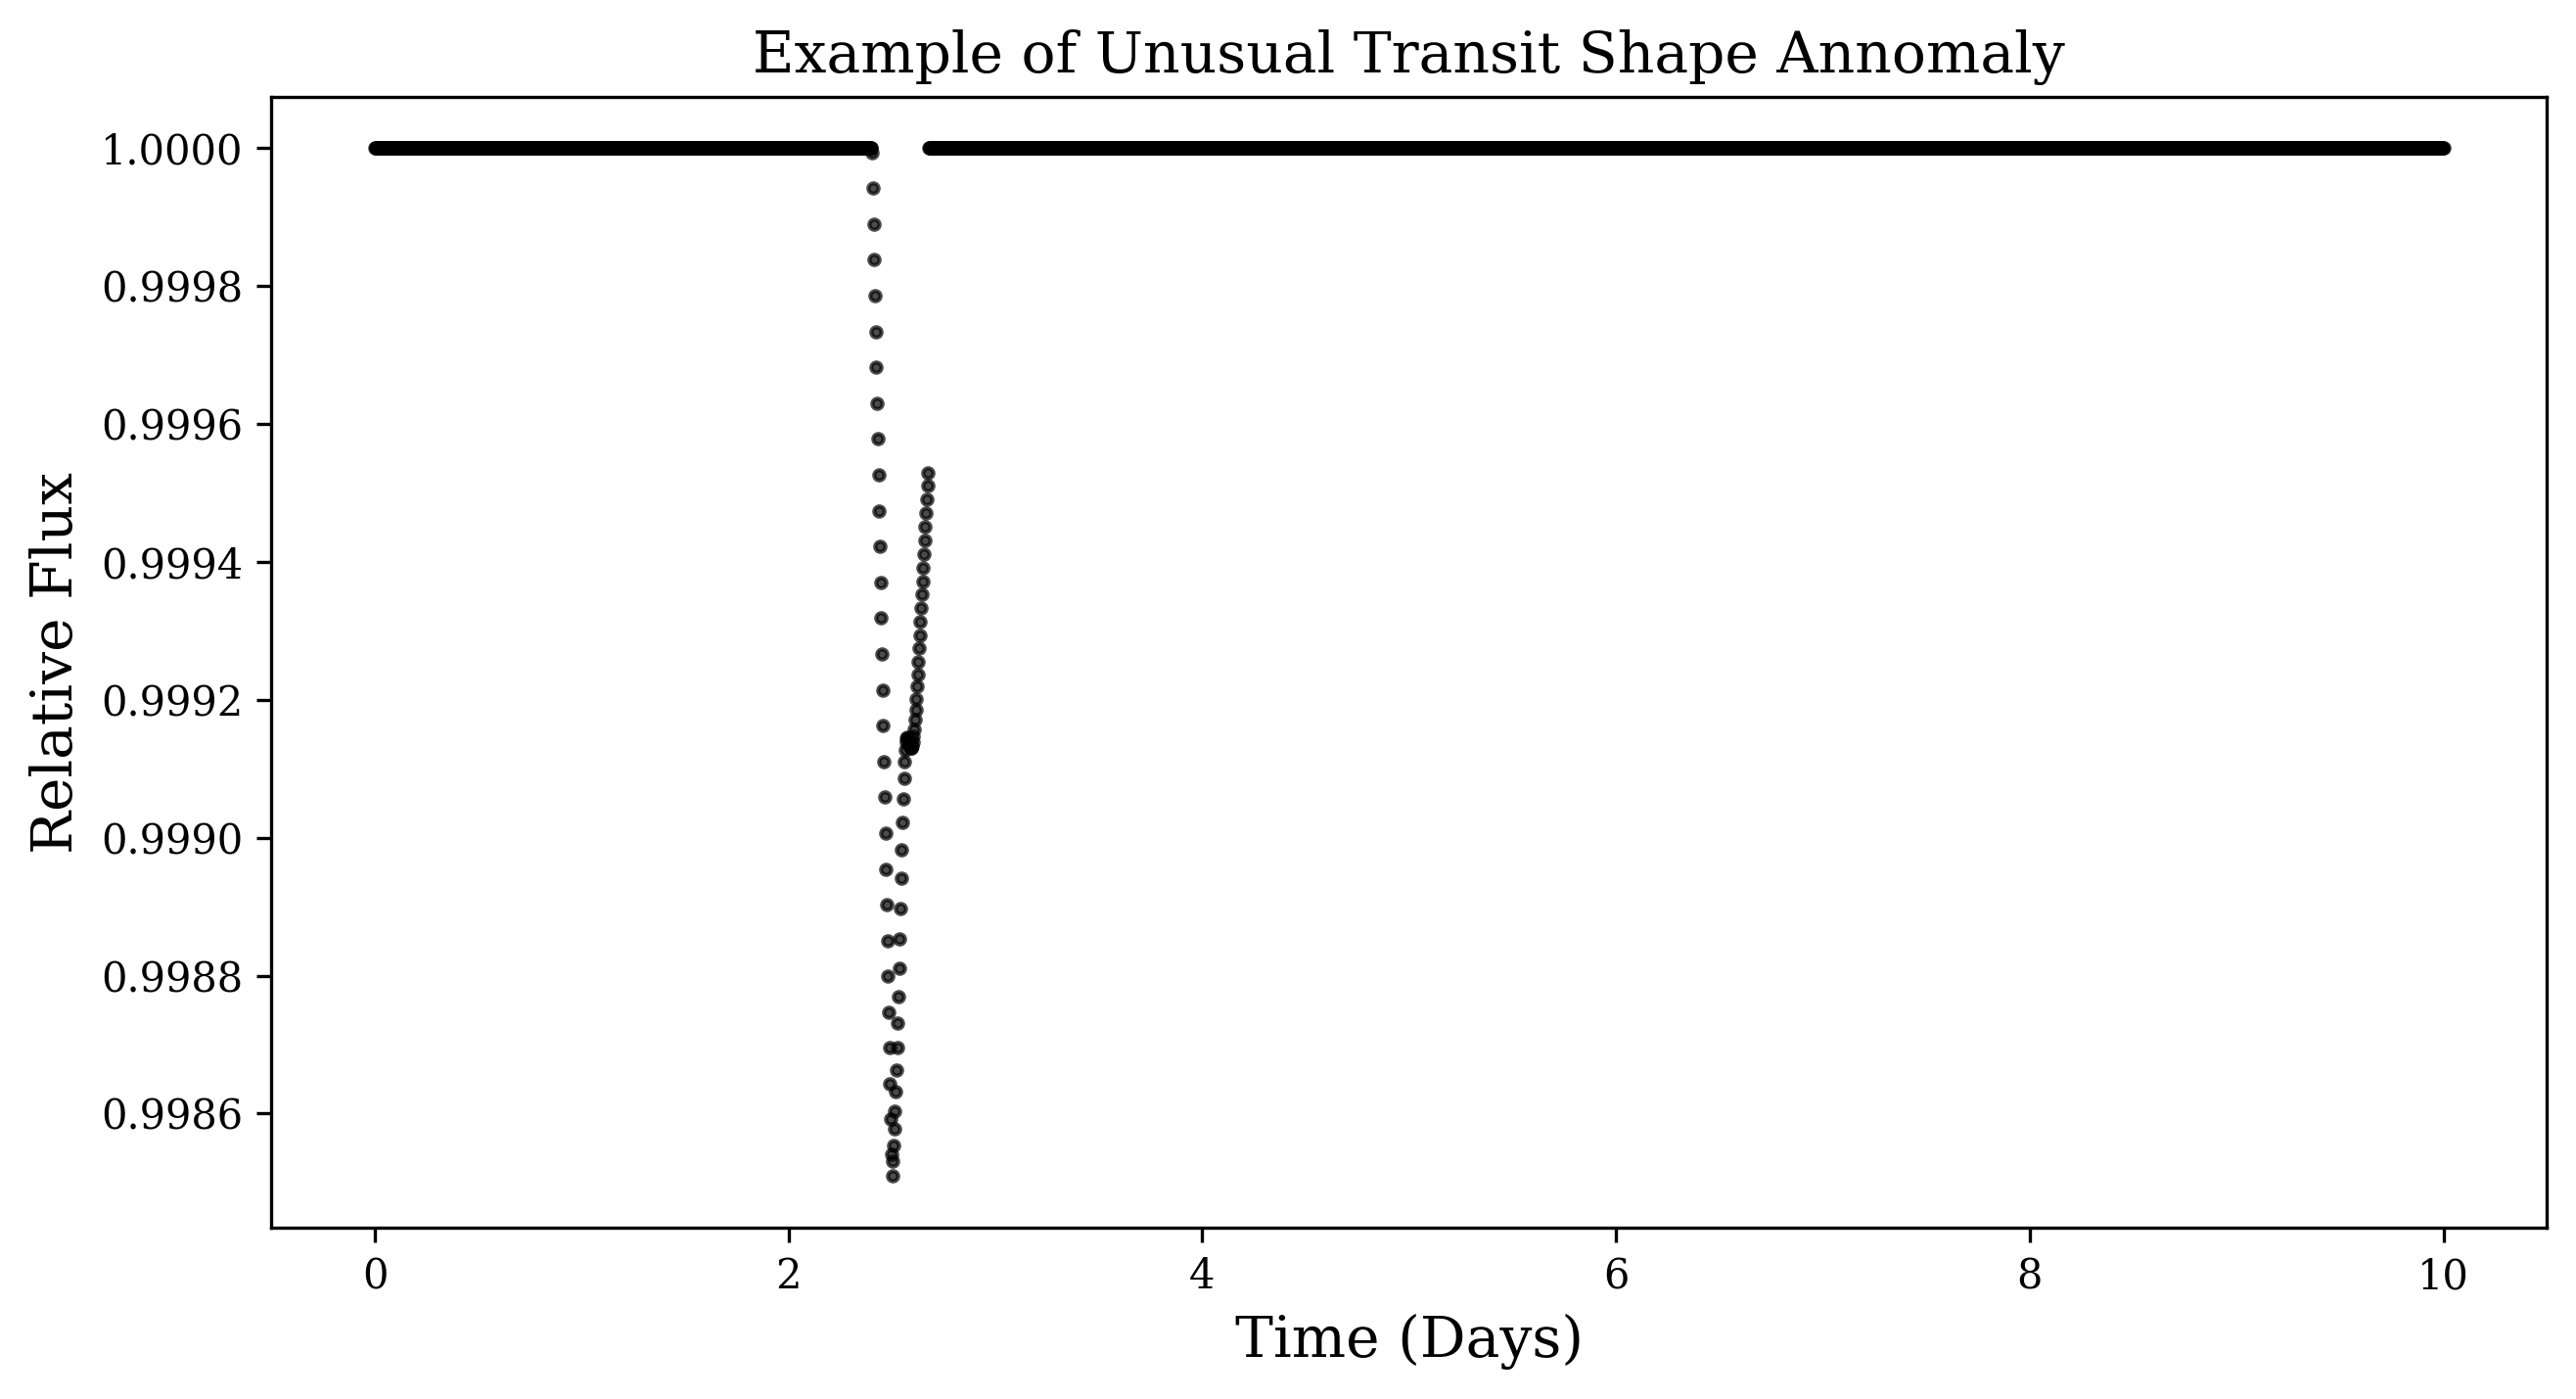

In [22]:
## lets plot the unusual transit shape with some example parameters to see what it looks like
time = np.linspace(0, 10, 3000)
flux = np.ones_like(time)
injected_flux, signal_ppm, used_params = inject_anomaly(
    time, flux, kind="unusual_transit_shape", rng=10, period_days=12.0, t0_day=2.5, depth_ppm=1500.0, duration_days=0.35, asymmetry=0.45, shoulder_ppm=250.0
)
plt.figure(figsize=(10, 5))
plt.plot(time, injected_flux, color='black', marker='.', markersize=5, linestyle='none', alpha=0.7)
plt.title("Example of Unusual Transit Shape Annomaly")
plt.xlabel("Time (Days)")
plt.ylabel("Relative Flux")
plt.show()

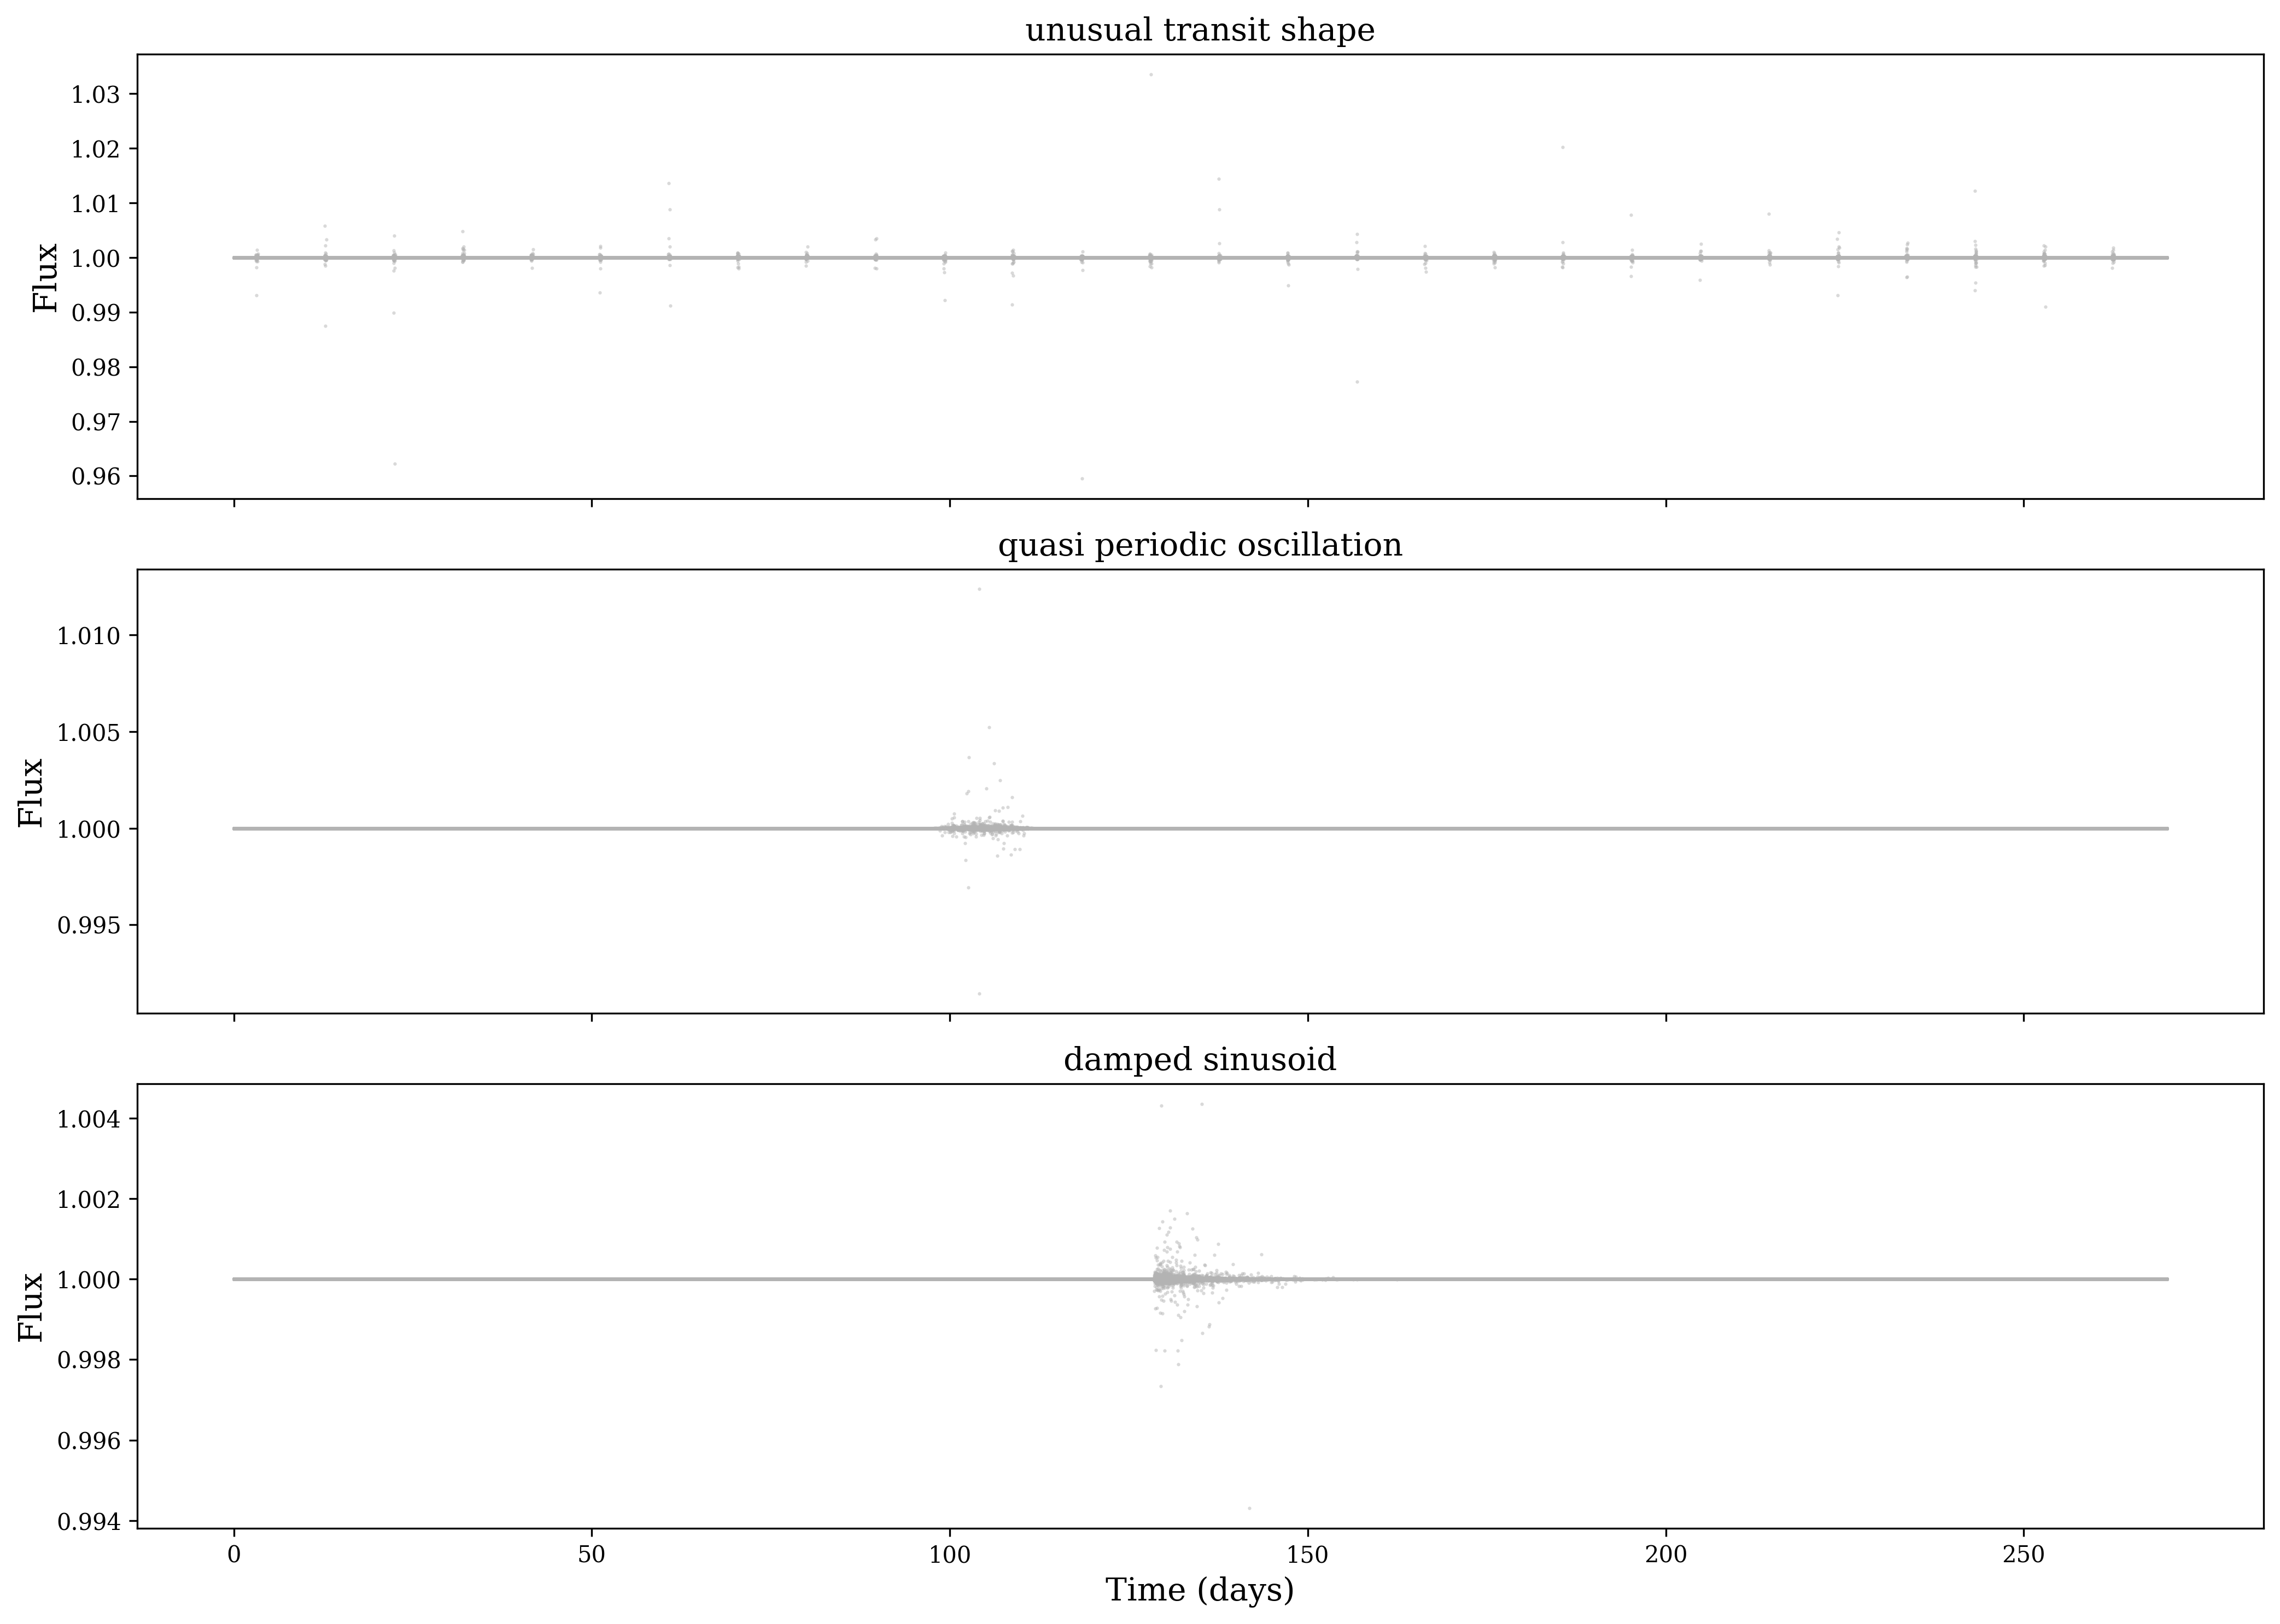

In [23]:
# Example: inject all four anomaly families into one generated light curve.
example_time, example_flux = load_lightcurve("outputs/sys_0000/")

if example_time is not None:
    anomaly_kinds = [
        "unusual_transit_shape",
        "quasi_periodic_oscillation",
        "damped_sinusoid",
    ]
    fig, axes = plt.subplots(len(anomaly_kinds), 1, figsize=(14, 10), sharex=True)
    days = time_to_days(example_time)

    for ax, kind in zip(axes, anomaly_kinds):
        flux_anom, signal_ppm, used_params = inject_anomaly(example_time, example_flux, kind)
        ax.plot(days, example_flux/flux_anom, ".", color="0.7", markersize=1, alpha=0.5, label="baseline")
        #ax.plot(days, flux_anom, ".", color="black", markersize=1, alpha=0.7, label="injected")
        ax.set_title(kind.replace("_", " "))
        ax.set_ylabel("Flux")

    axes[-1].set_xlabel("Time (days)")
    plt.tight_layout()
    plt.show()
else:
    print("Run the PSLS simulations first; outputs/sys_0000 was not found.")


## Phase 2: Probabilistic Modeling with celerite Gaussian Processes

The next cells fit a celerite Gaussian Process with a mixture of SHOTerm damped harmonic oscillator kernels, compute predictive distributions, and score new light curves by log likelihood under a baseline GP trained on normal variability.

In [24]:
def require_celerite():
    try:
        import celerite
        from celerite import terms
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "celerite is required for the GP section. Install it in this notebook kernel "
            "with `pip install celerite` or `conda install -c conda-forge celerite`."
        ) from exc
    return celerite, terms


def prepare_gp_data(time, flux, yerr=None, max_points=8_000):
    """Sort, clean, convert time to days, and center flux in ppm for celerite."""
    t = time_to_days(time)
    flux = np.asarray(flux, dtype=float)
    if ppm_flux_scale(flux) == 1.0:
        y = flux - np.nanmedian(flux)
    else:
        y = 1e6 * (flux - np.nanmedian(flux))

    finite = np.isfinite(t) & np.isfinite(y)
    t = t[finite]
    y = y[finite]
    order = np.argsort(t)
    t = t[order]
    y = y[order]

    if yerr is None:
        dy = np.diff(y)
        sigma = 1.4826 * np.nanmedian(np.abs(dy - np.nanmedian(dy))) / np.sqrt(2.0)
        sigma = float(max(sigma, 1.0))
        yerr = np.full_like(y, sigma)
    else:
        yerr = np.asarray(yerr, dtype=float)
        yerr = yerr[finite][order] if yerr.ndim else np.full_like(y, float(yerr))
        yerr = np.maximum(yerr, 1e-6)

    if max_points is not None and len(t) > max_points:
        idx = np.linspace(0, len(t) - 1, max_points).astype(int)
        t, y, yerr = t[idx], y[idx], yerr[idx]

    unique = np.concatenate([[True], np.diff(t) > 0])
    return t[unique], y[unique], yerr[unique]


def build_sho_mixture_kernel(y, yerr, periods_days=(0.2, 2.0), q_values=(1 / np.sqrt(2), 2.0)):
    celerite, terms = require_celerite()
    variance = float(max(np.nanvar(y), np.nanmedian(yerr) ** 2, 1.0))
    kernel = None

    for period, q_value in zip(periods_days, q_values):
        component = terms.SHOTerm(
            log_S0=np.log(variance / len(periods_days)),
            log_Q=np.log(q_value),
            log_omega0=np.log(2.0 * np.pi / period),
        )
        kernel = component if kernel is None else kernel + component

    kernel += terms.JitterTerm(log_sigma=np.log(float(max(np.nanmedian(yerr), 1e-6))))
    return kernel


def fit_celerite_gp(time, flux, yerr=None, periods_days=(0.2, 2.0), max_points=8_000):
    """Fit a celerite GP to a light curve and return gp, cleaned arrays, and optimizer result."""
    celerite, _ = require_celerite()
    t, y, yerr = prepare_gp_data(time, flux, yerr=yerr, max_points=max_points)
    gp = celerite.GP(build_sho_mixture_kernel(y, yerr, periods_days=periods_days), mean=0.0)
    gp.compute(t, yerr)

    def nll(params):
        gp.set_parameter_vector(params)
        try:
            gp.compute(t, yerr)
            value = -gp.log_likelihood(y)
        except Exception:
            return np.inf
        return value if np.isfinite(value) else np.inf

    initial_params = gp.get_parameter_vector()
    soln = minimize(nll, initial_params, method="L-BFGS-B")
    gp.set_parameter_vector(soln.x)
    gp.compute(t, yerr)
    return gp, t, y, yerr, soln


def gp_predict(gp, t_train, y_train, points=5_000):
    x_pred = np.linspace(np.nanmin(t_train), np.nanmax(t_train), points)
    mu, var = gp.predict(y_train, x_pred, return_var=True)
    return x_pred, mu, np.sqrt(np.maximum(var, 0.0))


def score_lightcurve_with_gp(gp, time, flux, yerr=None, max_points=8_000):
    """Compute average GP log likelihood for a candidate light curve."""
    t, y, yerr = prepare_gp_data(time, flux, yerr=yerr, max_points=max_points)
    gp.compute(t, yerr)
    return gp.log_likelihood(y) / len(y)


def build_baseline_likelihood_distribution(df, n_baseline=25, max_points=4_000):
    """Fit normal systems and approximate their per-point log likelihood as a Gaussian."""
    normal_rows = df[df["anomaly_class"] == 0].head(n_baseline)
    records = []

    for _, row in normal_rows.iterrows():
        time, flux = load_lightcurve(f"outputs/{row['system_id']}/")
        if time is None:
            continue
        gp, t, y, yerr, soln = fit_celerite_gp(time, flux, max_points=max_points)
        loglike_per_point = gp.log_likelihood(y) / len(y)
        records.append({
            "system_id": row["system_id"],
            "loglike_per_point": loglike_per_point,
            "optimizer_success": bool(soln.success),
            **gp.get_parameter_dict(),
        })

    baseline = pd.DataFrame(records)
    mu = float(baseline["loglike_per_point"].mean())
    sigma = float(baseline["loglike_per_point"].std(ddof=1))
    return baseline, mu, sigma


def flag_gp_anomaly(loglike_per_point, baseline_mu, baseline_sigma, alpha=0.01):
    """One-sided low-likelihood Bayesian-style anomaly score from a normal baseline."""
    if not np.isfinite(baseline_sigma) or baseline_sigma <= 0:
        return {"p_low": np.nan, "is_anomaly": False}
    p_low = norm.cdf(loglike_per_point, loc=baseline_mu, scale=baseline_sigma)
    return {"p_low": float(p_low), "is_anomaly": bool(p_low < alpha)}


Optimizer success: True
Per-point log likelihood: -20.921
OrderedDict([('kernel:terms[0]:log_S0', 26.76380020784807), ('kernel:terms[0]:log_Q', -4.881035100428549), ('kernel:terms[0]:log_omega0', -0.1882465670241965), ('kernel:terms[1]:log_S0', 26.05060092781474), ('kernel:terms[1]:log_Q', 9.96661645270279), ('kernel:terms[1]:log_omega0', -2.6766721684627126), ('kernel:terms[2]:log_sigma', 17.86734063610724)])


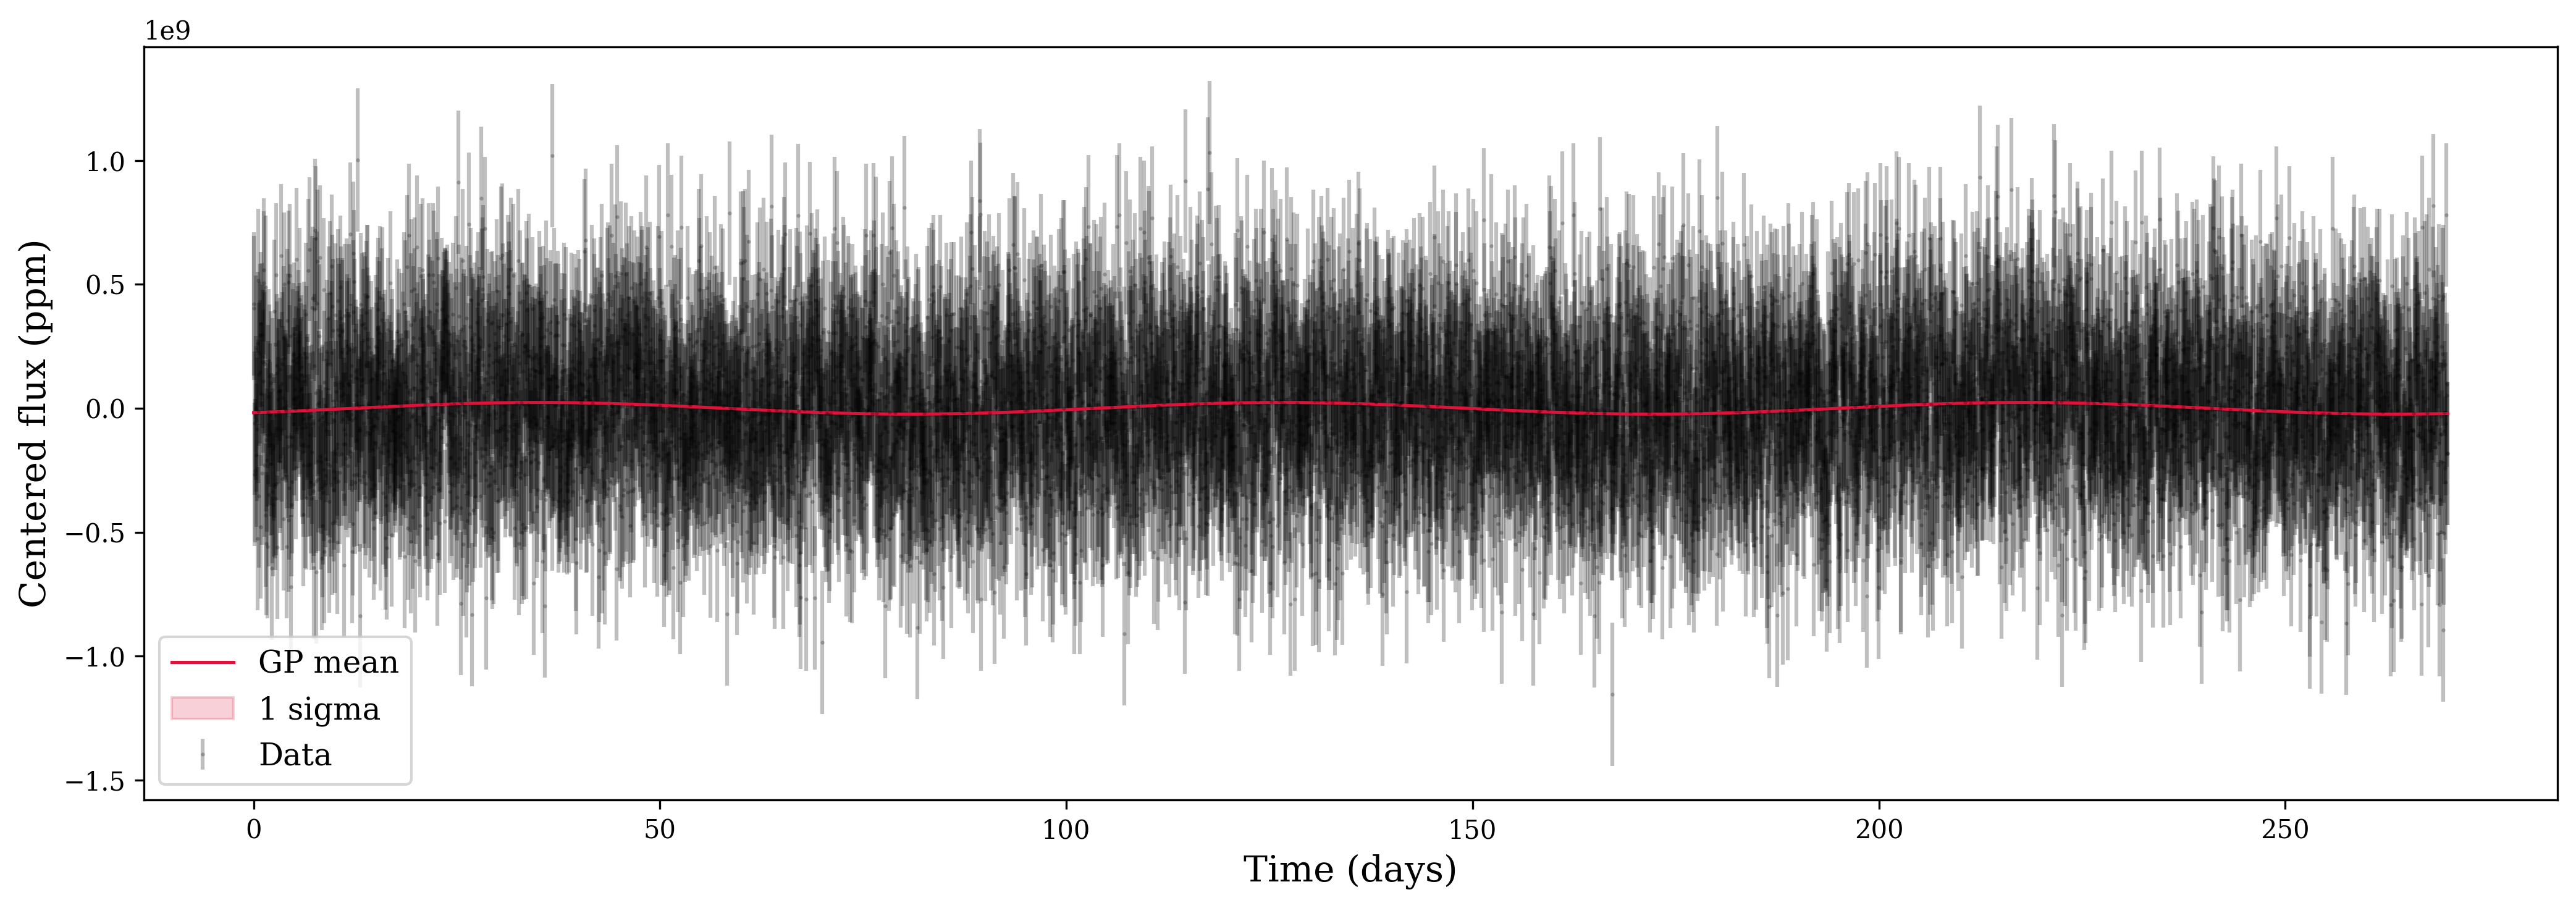

In [25]:
# Example GP fit and predictive distribution for one normal light curve.
# This cell requires celerite in the active kernel.
normal_candidates = df[df["anomaly_class"] == 0]["system_id"].tolist()

if normal_candidates:
    gp_time, gp_flux = load_lightcurve(f"outputs/{normal_candidates[0]}/")
    if gp_time is not None:
        gp, t_gp, y_gp, yerr_gp, soln = fit_celerite_gp(gp_time, gp_flux, max_points=6_000)
        x_pred, mu, std = gp_predict(gp, t_gp, y_gp)

        print(f"Optimizer success: {soln.success}")
        print(f"Per-point log likelihood: {gp.log_likelihood(y_gp) / len(y_gp):.3f}")
        print(gp.get_parameter_dict())

        plt.figure(figsize=(14, 5))
        plt.errorbar(t_gp, y_gp, yerr=yerr_gp, fmt=".k", markersize=1, alpha=0.25, label="Data")
        plt.plot(x_pred, mu, color="crimson", lw=1.2, label="GP mean")
        plt.fill_between(x_pred, mu - std, mu + std, color="crimson", alpha=0.2, label="1 sigma")
        plt.xlabel("Time (days)")
        plt.ylabel("Centered flux (ppm)")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Run the PSLS simulations first; no normal light curve output was found.")
else:
    print("No anomaly_class == 0 systems found in df.")


In [ ]:
# Example anomaly detection workflow.
# Train the baseline on normal light curves, then score a few mixed systems.
baseline_gp_df, baseline_mu, baseline_sigma = build_baseline_likelihood_distribution(
    df,
    n_baseline=10,
    max_points=3_000,
)

score_records = []
for _, row in df.head(20).iterrows():
    time, flux = load_lightcurve(f"outputs/{row['system_id']}/")
    if time is None:
        continue
    gp, t, y, yerr, soln = fit_celerite_gp(time, flux, max_points=3_000)
    ll = gp.log_likelihood(y) / len(y)
    decision = flag_gp_anomaly(ll, baseline_mu, baseline_sigma, alpha=0.01)
    score_records.append({
        "system_id": row["system_id"],
        "true_class": row["anomaly_class"],
        "loglike_per_point": ll,
        **decision,
    })

gp_scores = pd.DataFrame(score_records)
display(gp_scores.sort_values("p_low"))


,system_id,true_class,loglike_per_point,p_low,is_anomaly
14,sys_0014,3,-22.330406,0.000000e+00,True
5,sys_0005,1,-21.500069,0.000000e+00,True
6,sys_0006,3,-22.280397,0.000000e+00,True
18,sys_0018,1,-21.624794,0.000000e+00,True
11,sys_0011,1,-21.995259,0.000000e+00,True
4,sys_0004,1,-21.440487,5.364211e-259,True
13,sys_0013,3,-21.334116,9.227169e-163,True
10,sys_0010,3,-21.322961,5.690970e-154,True
2,sys_0002,1,-21.081778,3.047534e-24,True
7,sys_0007,3,-20.979862,6.981005e-04,True


In [26]:
def analyze_bin_differences(df):
    clean_df = df[df['anomaly_class'] == 0].copy()
    
    bins = {
        "4-5k K": clean_df[(clean_df['star_teff'] >= 4000) & (clean_df['star_teff'] < 5000)],
        "5-6k K": clean_df[(clean_df['star_teff'] >= 5000) & (clean_df['star_teff'] < 6000)],
        "6k+ K": clean_df[clean_df['star_teff'] >= 6000]
    }
    
    fig, (ax_res, ax_dist) = plt.subplots(2, 1, figsize=(14, 12))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    print("--- Bin Statistics ---")
    for i, (label, sub_df) in enumerate(bins.items()):
        n_count = len(sub_df)
        print(f"{label}: {n_count} systems successfully generated.")
        
        if n_count > 0:
            # Pick the representative star
            median_idx = sub_df['star_teff'].argsort().iloc[n_count // 2]
            sys_id = sub_df.iloc[median_idx]['system_id']
            
            t, f = load_lightcurve(f"outputs/{sys_id}")
            if t is not None:
                # Calculate Residuals in ppm (parts per million) for clarity
                residuals_ppm = (f - 1.0)
                
                # 1-day window mask
                mask = (t/86400 >= 0) & (t/86400 <= 20000)
                
                # Plot Residual Overlay
                ax_res.plot(t[mask]/86400, residuals_ppm[mask], 
                            color=colors[i], label=f"{label} (RMS: {np.std(residuals_ppm):.1f})", 
                            alpha=0.8, lw=1)
                
                # Plot Histogram of the Residuals to show "Noise Width"
                ax_dist.hist(residuals_ppm, bins=100, histtype='step', 
                             color=colors[i], lw=2, label=label, density=True)

    ax_res.set_title("Stellar Noise Residuals (1-Day Window)")
    ax_res.set_ylabel("Residual Flux (ppm)")
    ax_res.legend(loc='upper right')
    
    ax_dist.set_title("Distribution of Residuals (The Noise Profile)")
    ax_dist.set_xlabel("Deviation from Mean (ppm)")
    ax_dist.set_ylabel("Density")
    ax_dist.legend()
    
    plt.tight_layout()
    plt.show()

analyze_bin_differences(df)

--- Bin Statistics ---
4-5k K: 33 systems successfully generated.
5-6k K: 101 systems successfully generated.
6k+ K: 116 systems successfully generated.


KeyboardInterrupt: 

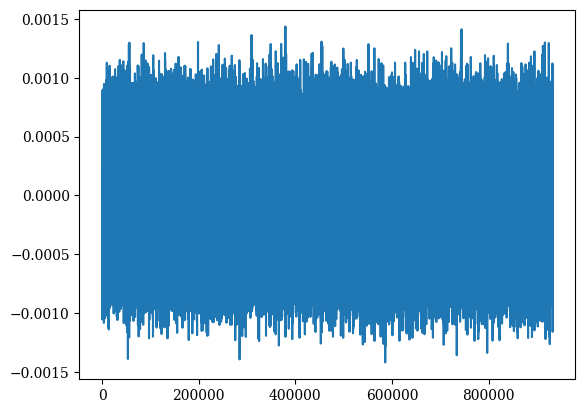

-11.927719846413316 301.94012337786404


In [ ]:
##plot one of the lightcurves

flux = load_lightcurve("outputs/sys_0000/")[1]
plt.plot(flux/1e6) 
plt.show()

print(np.mean(flux), np.std(flux))

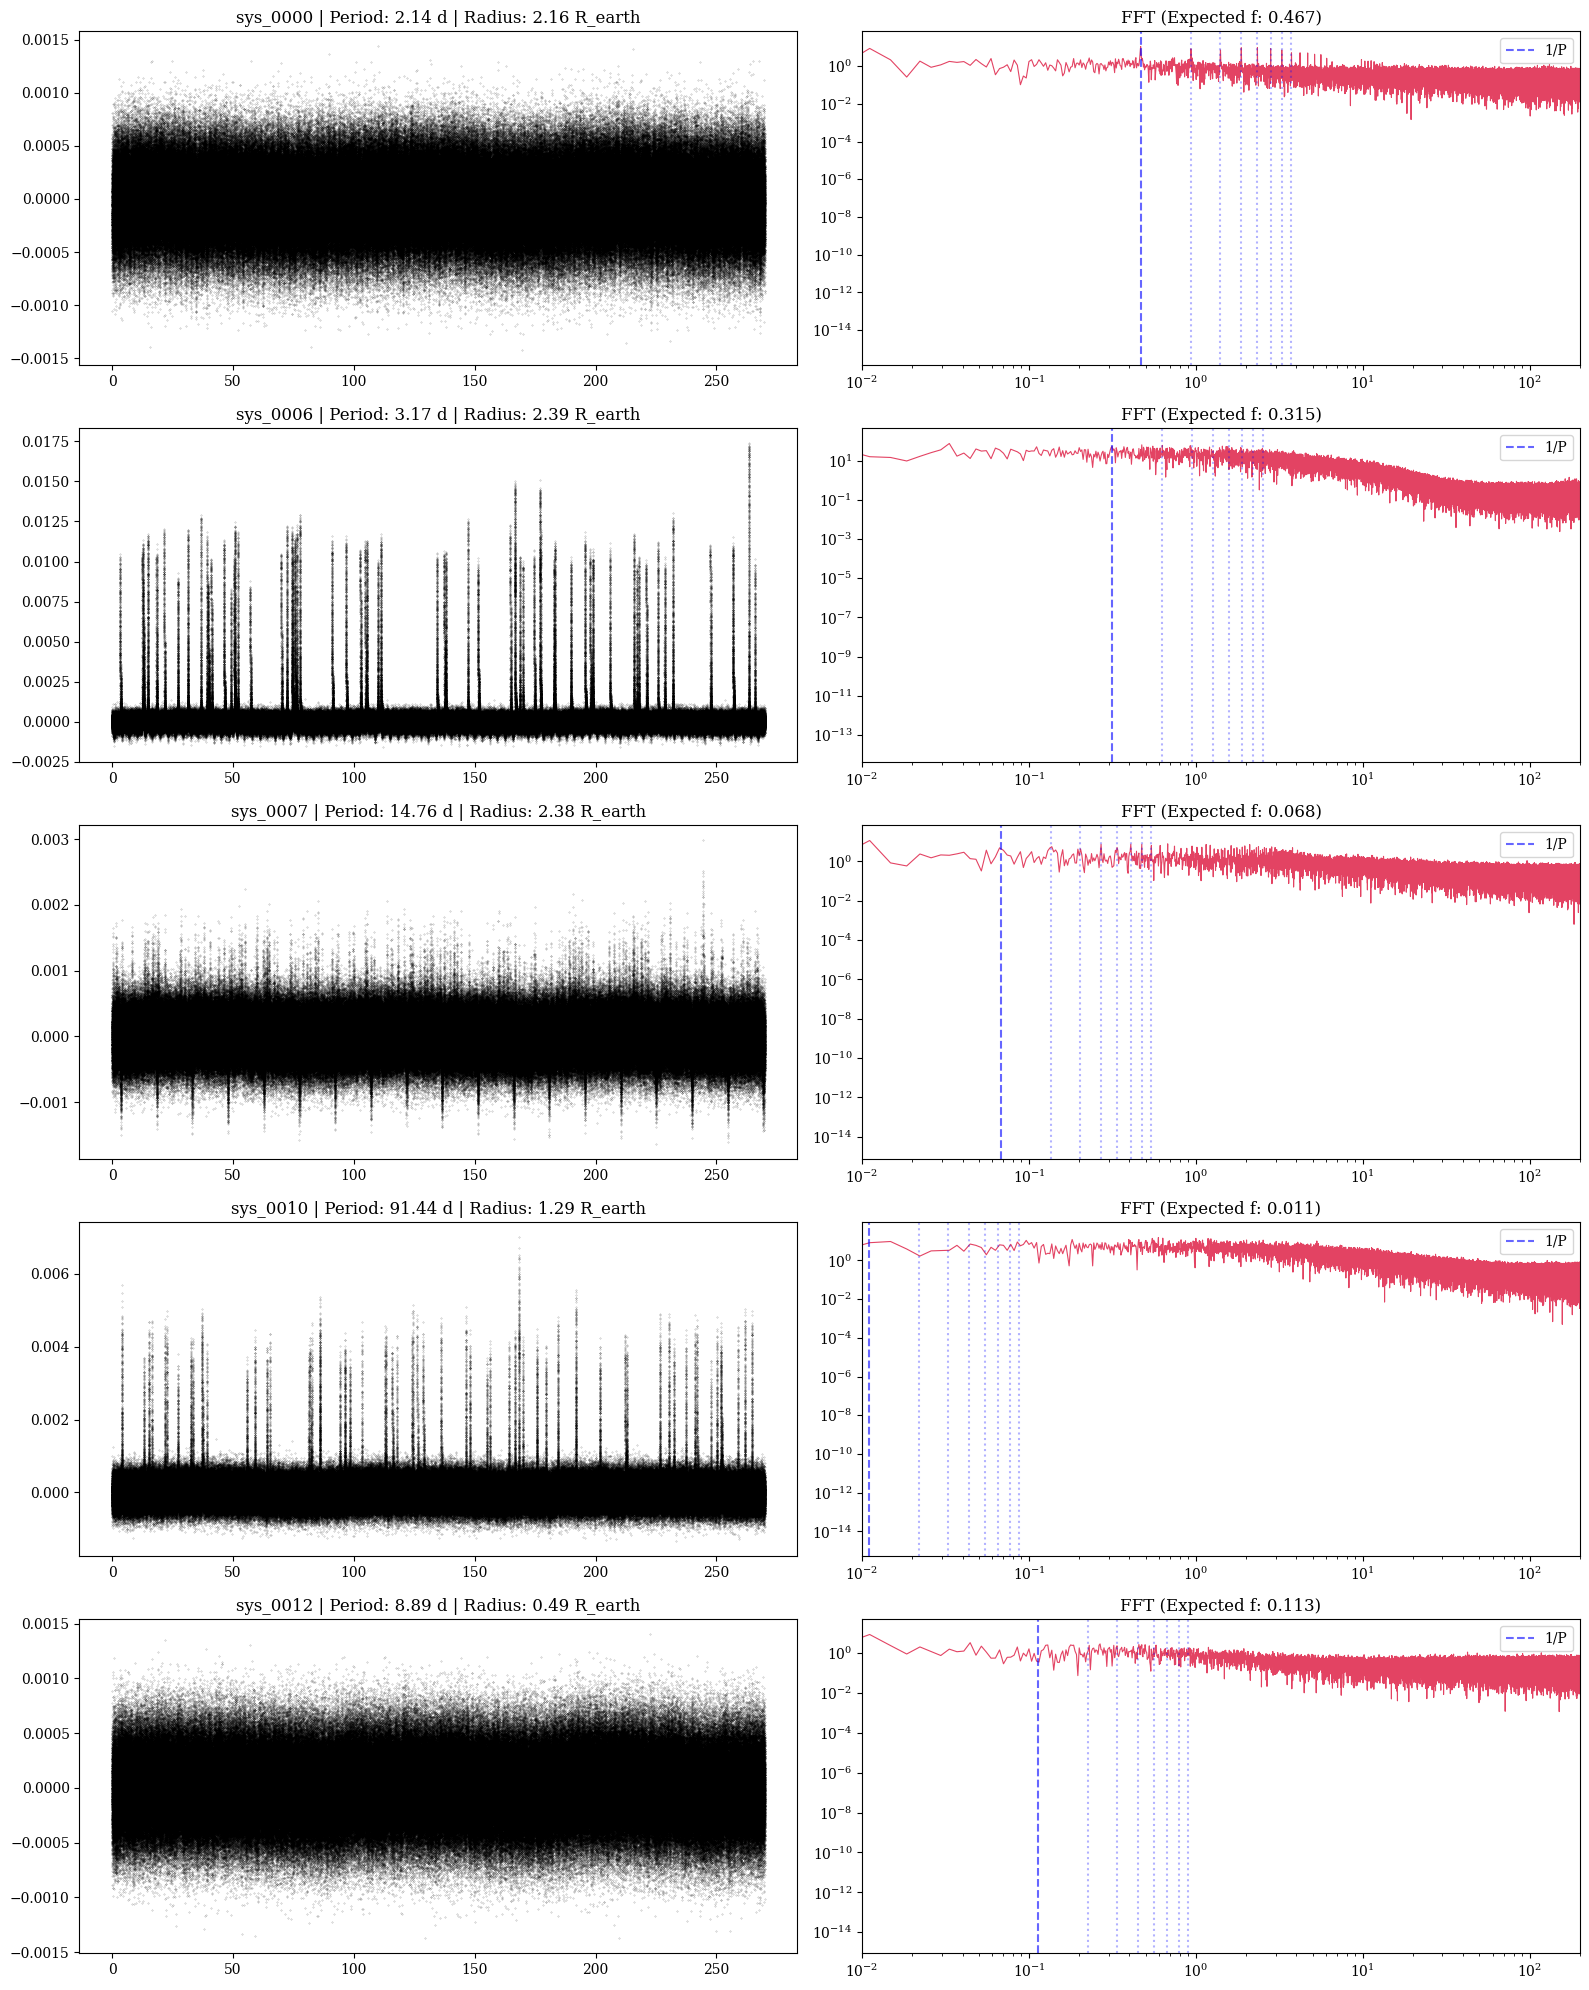

In [ ]:
# Filter for systems that actually have transits
transit_df = df[df['label_has_transit'] == 1].head(5)

fig, axes = plt.subplots(nrows=len(transit_df), ncols=2, figsize=(16, 4 * len(transit_df)))

for i, (_, row) in enumerate(transit_df.iterrows()):
    sys_id = row['system_id']
    period = row['transit_period']
    radius = row['transit_radius_earth']
    f_expected = 1.0 / period
    
    time, flux = load_lightcurve(f"outputs/{sys_id}/")

    flux /= 1e6 
    if time is None: continue
    
    # 1. Standardize Time to Days
    days = time / 86400
    dt = np.median(np.diff(days))
    
    # 2. FFT Calculation (with mean subtraction)
    flux_norm = flux - np.mean(flux)
    yf = np.abs(rfft(flux_norm))
    xf = rfftfreq(len(flux), dt)
    
    # --- Plot Light Curve ---
    ax_lc = axes[i, 0]
    ax_lc.plot(days, flux, 'k.', markersize=0.5, alpha=0.4)
    ax_lc.set_title(f"{sys_id} | Period: {period:.2f} d | Radius: {radius:.2f} R_earth")
    
    # --- Plot FFT ---
    ax_fft = axes[i, 1]
    ax_fft.plot(xf, yf, color='crimson', lw=0.8, alpha=0.8)
    
    # Mark expected frequency and first 3 harmonics
    ax_fft.axvline(f_expected, color='blue', linestyle='--', alpha=0.6, label='1/P')
    for h in range(2, 9):
        ax_fft.axvline(f_expected * h, color='blue', linestyle=':', alpha=0.3)
    
    ax_fft.set_yscale('log')
    ax_fft.set_xscale('log')
    ax_fft.set_xlim(0.01, 200) # Focusing on the low-frequency "signal" zone
    ax_fft.set_title(f"FFT (Expected f: {f_expected:.3f})")
    ax_fft.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Transit Classifier: Transit vs. No Transit

This section trains a binary classifier from light-curve measurements only. It ignores the anomaly labels and does not use `transit_period` or `transit_radius_earth` as features; those are kept only as ground-truth labels/evaluation context.

In [34]:
from astropy.timeseries import BoxLeastSquares
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

def load_classifier_lightcurve(folder_path):
    """Load a classifier light curve, preferring PSLS .dat files to avoid HDF5 dependency issues."""
    dat_files = glob.glob(os.path.join(folder_path, "*.dat"))
    if dat_files:
        data_rows = []
        with open(dat_files[0], "r") as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                try:
                    data_rows.append([float(p) for p in parts])
                except ValueError:
                    continue
        data = np.asarray(data_rows, dtype=float)
        if data.ndim == 2 and data.shape[1] >= 2:
            return data[:, 0], data[:, 1]

    h5_files = glob.glob(os.path.join(folder_path, "*.hdf5")) + glob.glob(os.path.join(folder_path, "*.h5"))
    if h5_files:
        try:
            import h5py
            with h5py.File(h5_files[0], "r") as f:
                if "time" in f and "flux" in f:
                    return f["time"][:], f["flux"][:]
                keys = list(f.keys())
                return f[keys[0]][:], f[keys[1]][:]
        except Exception as exc:
            print(f"Could not read HDF5 light curve {h5_files[0]}: {exc}")

    return None, None

def lightcurve_to_ppm(time, flux, max_points=6_000):
    """Clean light curve data that is already in ppm."""
    t = time_to_days(time)
    flux = np.asarray(flux, dtype=float)
    
    # Filter for finite values
    finite = np.isfinite(t) & np.isfinite(flux)
    t = t[finite]
    flux = flux[finite]

    # Ensure chronological order
    order = np.argsort(t)
    t = t[order]
    flux = flux[order]

    # Since it's already in ppm, we just want to ensure it's median-centered at 0
    y_ppm = flux - np.nanmedian(flux)

    # Downsample for performance if necessary
    if max_points is not None and len(t) > max_points:
        idx = np.linspace(0, len(t) - 1, max_points).astype(int)
        t = t[idx]
        y_ppm = y_ppm[idx]

    unique = np.concatenate([[True], np.diff(t) > 0])
    return t[unique], y_ppm[unique]

def robust_noise_ppm(y_ppm):
    dy = np.diff(y_ppm)
    if len(dy) == 0:
        return np.nan
    sigma = 1.4826 * np.nanmedian(np.abs(dy - np.nanmedian(dy))) / np.sqrt(2.0)
    return float(sigma) if np.isfinite(sigma) and sigma > 0 else float(np.nanstd(y_ppm))

def extract_bls_features(t_days, y_ppm, min_period=2.0, max_period=100.0,
                         n_periods=160, durations=(0.08, 0.16, 0.32, 0.64)):
    """Box Least Squares transit-search features for a single light curve."""
    span = float(np.nanmax(t_days) - np.nanmin(t_days))
    max_period = min(max_period, 0.8 * span)
    min_period = min(min_period, max_period / 2.0)
    if len(t_days) < 20 or not np.isfinite(max_period) or max_period <= min_period:
        return {
            "bls_power": np.nan,
            "bls_period": np.nan,
            "bls_duration": np.nan,
            "bls_depth_ppm": np.nan,
            "bls_depth_snr": np.nan,
            "bls_transit_time": np.nan,
        }

    periods = np.geomspace(min_period, max_period, n_periods)
    dy_ppm = np.full_like(y_ppm, max(robust_noise_ppm(y_ppm), 1.0))
    model = BoxLeastSquares(t_days, y_ppm, dy=dy_ppm)

    try:
        result = model.power(periods, np.asarray(durations), objective="snr")
        power = np.ravel(result.power).astype(float)
        finite_power = np.where(np.isfinite(power), power, np.nan)
        if np.all(np.isnan(finite_power)):
            raise ValueError("BLS returned no finite powers")

        best = int(np.nanargmax(finite_power))
        depth = float(np.ravel(result.depth)[best])
        depth_err = float(np.ravel(result.depth_err)[best])
        depth_snr = float(abs(depth) / depth_err) if depth_err > 0 else np.nan

        values = {
            "bls_power": float(finite_power[best]),
            "bls_period": float(np.ravel(result.period)[best]),
            "bls_duration": float(np.ravel(result.duration)[best]),
            "bls_depth_ppm": depth,
            "bls_depth_snr": depth_snr,
            "bls_transit_time": float(np.ravel(result.transit_time)[best]),
        }
        return {key: value if np.isfinite(value) else np.nan for key, value in values.items()}
    except Exception:
        return {
            "bls_power": np.nan,
            #"bls_period": np.nan,
            #"bls_duration": np.nan,
            "bls_depth_ppm": np.nan,
            "bls_depth_snr": np.nan,
            #"bls_transit_time": np.nan,
        }


def extract_transit_classifier_features(time, flux, max_points=6_000):
    """Feature vector for transit/no-transit classification."""
    t_days, y_ppm = lightcurve_to_ppm(time, flux, max_points=max_points)
    sigma = robust_noise_ppm(y_ppm)
    percentiles = np.nanpercentile(y_ppm, [1, 5, 10, 50, 90, 95, 99])
    centered = y_ppm - np.nanmedian(y_ppm)

    features = {
        #"n_points": len(y_ppm),
        #"time_span_days": float(np.nanmax(t_days) - np.nanmin(t_days)),
        #"cadence_days": float(np.nanmedian(np.diff(t_days))) if len(t_days) > 1 else np.nan,
        "flux_std_ppm": float(np.nanstd(y_ppm)),
        #"noise_ppm": sigma,
        "skew": float(skew(centered, nan_policy="omit")),
        #"kurtosis": float(kurtosis(centered, nan_policy="omit")),
        "p01_ppm": float(percentiles[0]),
        "p05_ppm": float(percentiles[1]),
        #"p10_ppm": float(percentiles[2]),
        #"p90_ppm": float(percentiles[4]),
        "p95_ppm": float(percentiles[5]),
        "p99_ppm": float(percentiles[6]),
        #"low_tail_width_ppm": float(percentiles[3] - percentiles[0]),
        #"high_tail_width_ppm": float(percentiles[6] - percentiles[3]),
        "negative_outlier_fraction": float(np.mean(y_ppm < -3.0 * sigma)) if np.isfinite(sigma) and sigma > 0 else np.nan,
    }
    features.update(extract_bls_features(t_days, y_ppm))
    return features


def build_transit_feature_table(labels_df, max_systems=None, max_points=6_000):
    """Build a modeling table from outputs/<system_id> light curves."""
    rows = []
    source_df = labels_df.copy()
    if max_systems is not None:
        source_df = source_df.head(max_systems)

    for _, row in tqdm(source_df.iterrows(), total=len(source_df), desc="Extracting transit features"):
        system_id = row["system_id"]
        time, flux = load_classifier_lightcurve(f"outputs/{system_id}/")
        if time is None:
            continue
        try:
            features = extract_transit_classifier_features(time, flux, max_points=max_points)
        except Exception as exc:
            print(f"Skipping {system_id}: {exc}")
            continue

        features.update({
            "system_id": system_id,
            "label_has_transit": int(row["label_has_transit"]),
        })
        rows.append(features)

    return pd.DataFrame(rows)


In [ ]:
# Build features and train the classifier.
# Use max_systems=None for the full dataset, or set a smaller number for faster iteration.
feature_df = build_transit_feature_table(df, max_systems=None, max_points=50_000)
print(feature_df.shape)
display(feature_df.head())

feature_cols = [
    col for col in feature_df.columns
    if col not in {"system_id", "label_has_transit"}
]
X = feature_df[feature_cols]
y = feature_df["label_has_transit"].astype(int)

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    feature_df["system_id"],
    test_size=0.25,
    random_state=42,
    stratify=y,
)

transit_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

transit_clf.fit(X_train, y_train)
proba = transit_clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Confusion matrix [[TN, FP], [FN, TP]]")
print(confusion_matrix(y_test, pred))
print("\nClassification report")
print(classification_report(y_test, pred, target_names=["no transit", "transit"]))
print(f"ROC AUC: {roc_auc_score(y_test, proba):.3f}")

results_df = pd.DataFrame({
    "system_id": ids_test.values,
    "true_has_transit": y_test.values,
    "pred_has_transit": pred,
    "p_transit": proba,
}).sort_values("p_transit", ascending=False)
 
display(results_df.head(15))
display(results_df.tail(15))


Extracting transit features:   0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 24)


,n_points,time_span_days,cadence_days,flux_std_ppm,noise_ppm,skew,kurtosis,p01_ppm,p05_ppm,p10_ppm,...,high_tail_width_ppm,negative_outlier_fraction,bls_power,bls_period,bls_duration,bls_depth_ppm,bls_depth_snr,bls_transit_time,system_id,label_has_transit
0,50000,269.999711,0.005498,295.584315,292.973696,-0.001836,-0.045800,-686.391822,-490.817329,-381.707604,...,681.292451,0.00120,6.187374,72.625729,0.32,118.030048,6.187374,4.37623,sys_0000,1
1,50000,269.999711,0.005498,293.952245,290.448326,-0.002489,-0.010678,-683.510722,-483.843204,-375.819797,...,682.319530,0.00164,6.076012,92.884653,0.32,161.968823,6.076012,91.85623,sys_0001,0
2,50000,269.999711,0.005498,347.014442,292.800361,2.804303,30.601555,-680.723006,-480.505167,-375.665272,...,762.698941,0.00136,6.990698,4.504498,0.32,35.614877,6.990698,2.58423,sys_0002,0
3,50000,269.999711,0.005498,298.036559,290.415111,0.032535,0.064259,-686.719463,-487.541559,-379.565967,...,702.246880,0.00164,6.788566,72.625729,0.64,90.891490,6.788566,22.94423,sys_0003,0
4,50000,269.999711,0.005498,548.157821,291.843586,7.143635,81.133345,-693.311858,-492.841247,-384.477172,...,1628.626333,0.00140,20.694242,3.038651,0.64,66.201085,20.694242,1.07223,sys_0004,0


Confusion matrix [[TN, FP], [FN, TP]]
[[109  16]
 [ 50  75]]

Classification report
              precision    recall  f1-score   support

  no transit       0.69      0.87      0.77       125
     transit       0.82      0.60      0.69       125

    accuracy                           0.74       250
   macro avg       0.75      0.74      0.73       250
weighted avg       0.75      0.74      0.73       250

ROC AUC: 0.793


,system_id,true_has_transit,pred_has_transit,p_transit
44,sys_0167,1,1,1.000000
50,sys_0769,1,1,1.000000
70,sys_0051,1,1,1.000000
122,sys_0353,1,1,1.000000
201,sys_0946,1,1,1.000000
198,sys_0440,1,1,1.000000
89,sys_0373,1,1,1.000000
185,sys_0544,1,1,0.999167
11,sys_0731,1,1,0.998750
161,sys_0950,1,1,0.998750


,system_id,true_has_transit,pred_has_transit,p_transit
78,sys_0334,0,0,0.187506
0,sys_0427,0,0,0.183000
46,sys_0213,0,0,0.176625
150,sys_0342,1,0,0.176333
228,sys_0666,0,0,0.174914
36,sys_0530,1,0,0.160083
9,sys_0446,0,0,0.158560
39,sys_0599,1,0,0.144875
208,sys_0331,0,0,0.144717
87,sys_0588,0,0,0.142208


In [41]:
# 1. Identify the False Negatives (True = Transit, Pred = No Transit)
false_negatives = results_df[(results_df['true_has_transit'] == 1) & (results_df['pred_has_transit'] == 0)]

# 2. Merge with the original feature table to see their physical properties
fn_analysis = false_negatives.merge(feature_df, on="system_id")

# 3. Compare Missed vs. Found Transits
true_positives = feature_df[(feature_df['system_id'].isin(ids_test)) & 
                            (feature_df['label_has_transit'] == 1) & 
                            (feature_df['system_id'].isin(results_df[results_df['pred_has_transit'] == 1]['system_id']))]

print("Average Depth of Found Planets:", true_positives['bls_depth_ppm'].median())
print("Average Depth of Missed Planets:", fn_analysis['bls_depth_ppm'].median())

Average Depth of Found Planets: 291.1720457161389
Average Depth of Missed Planets: 90.83225839678269


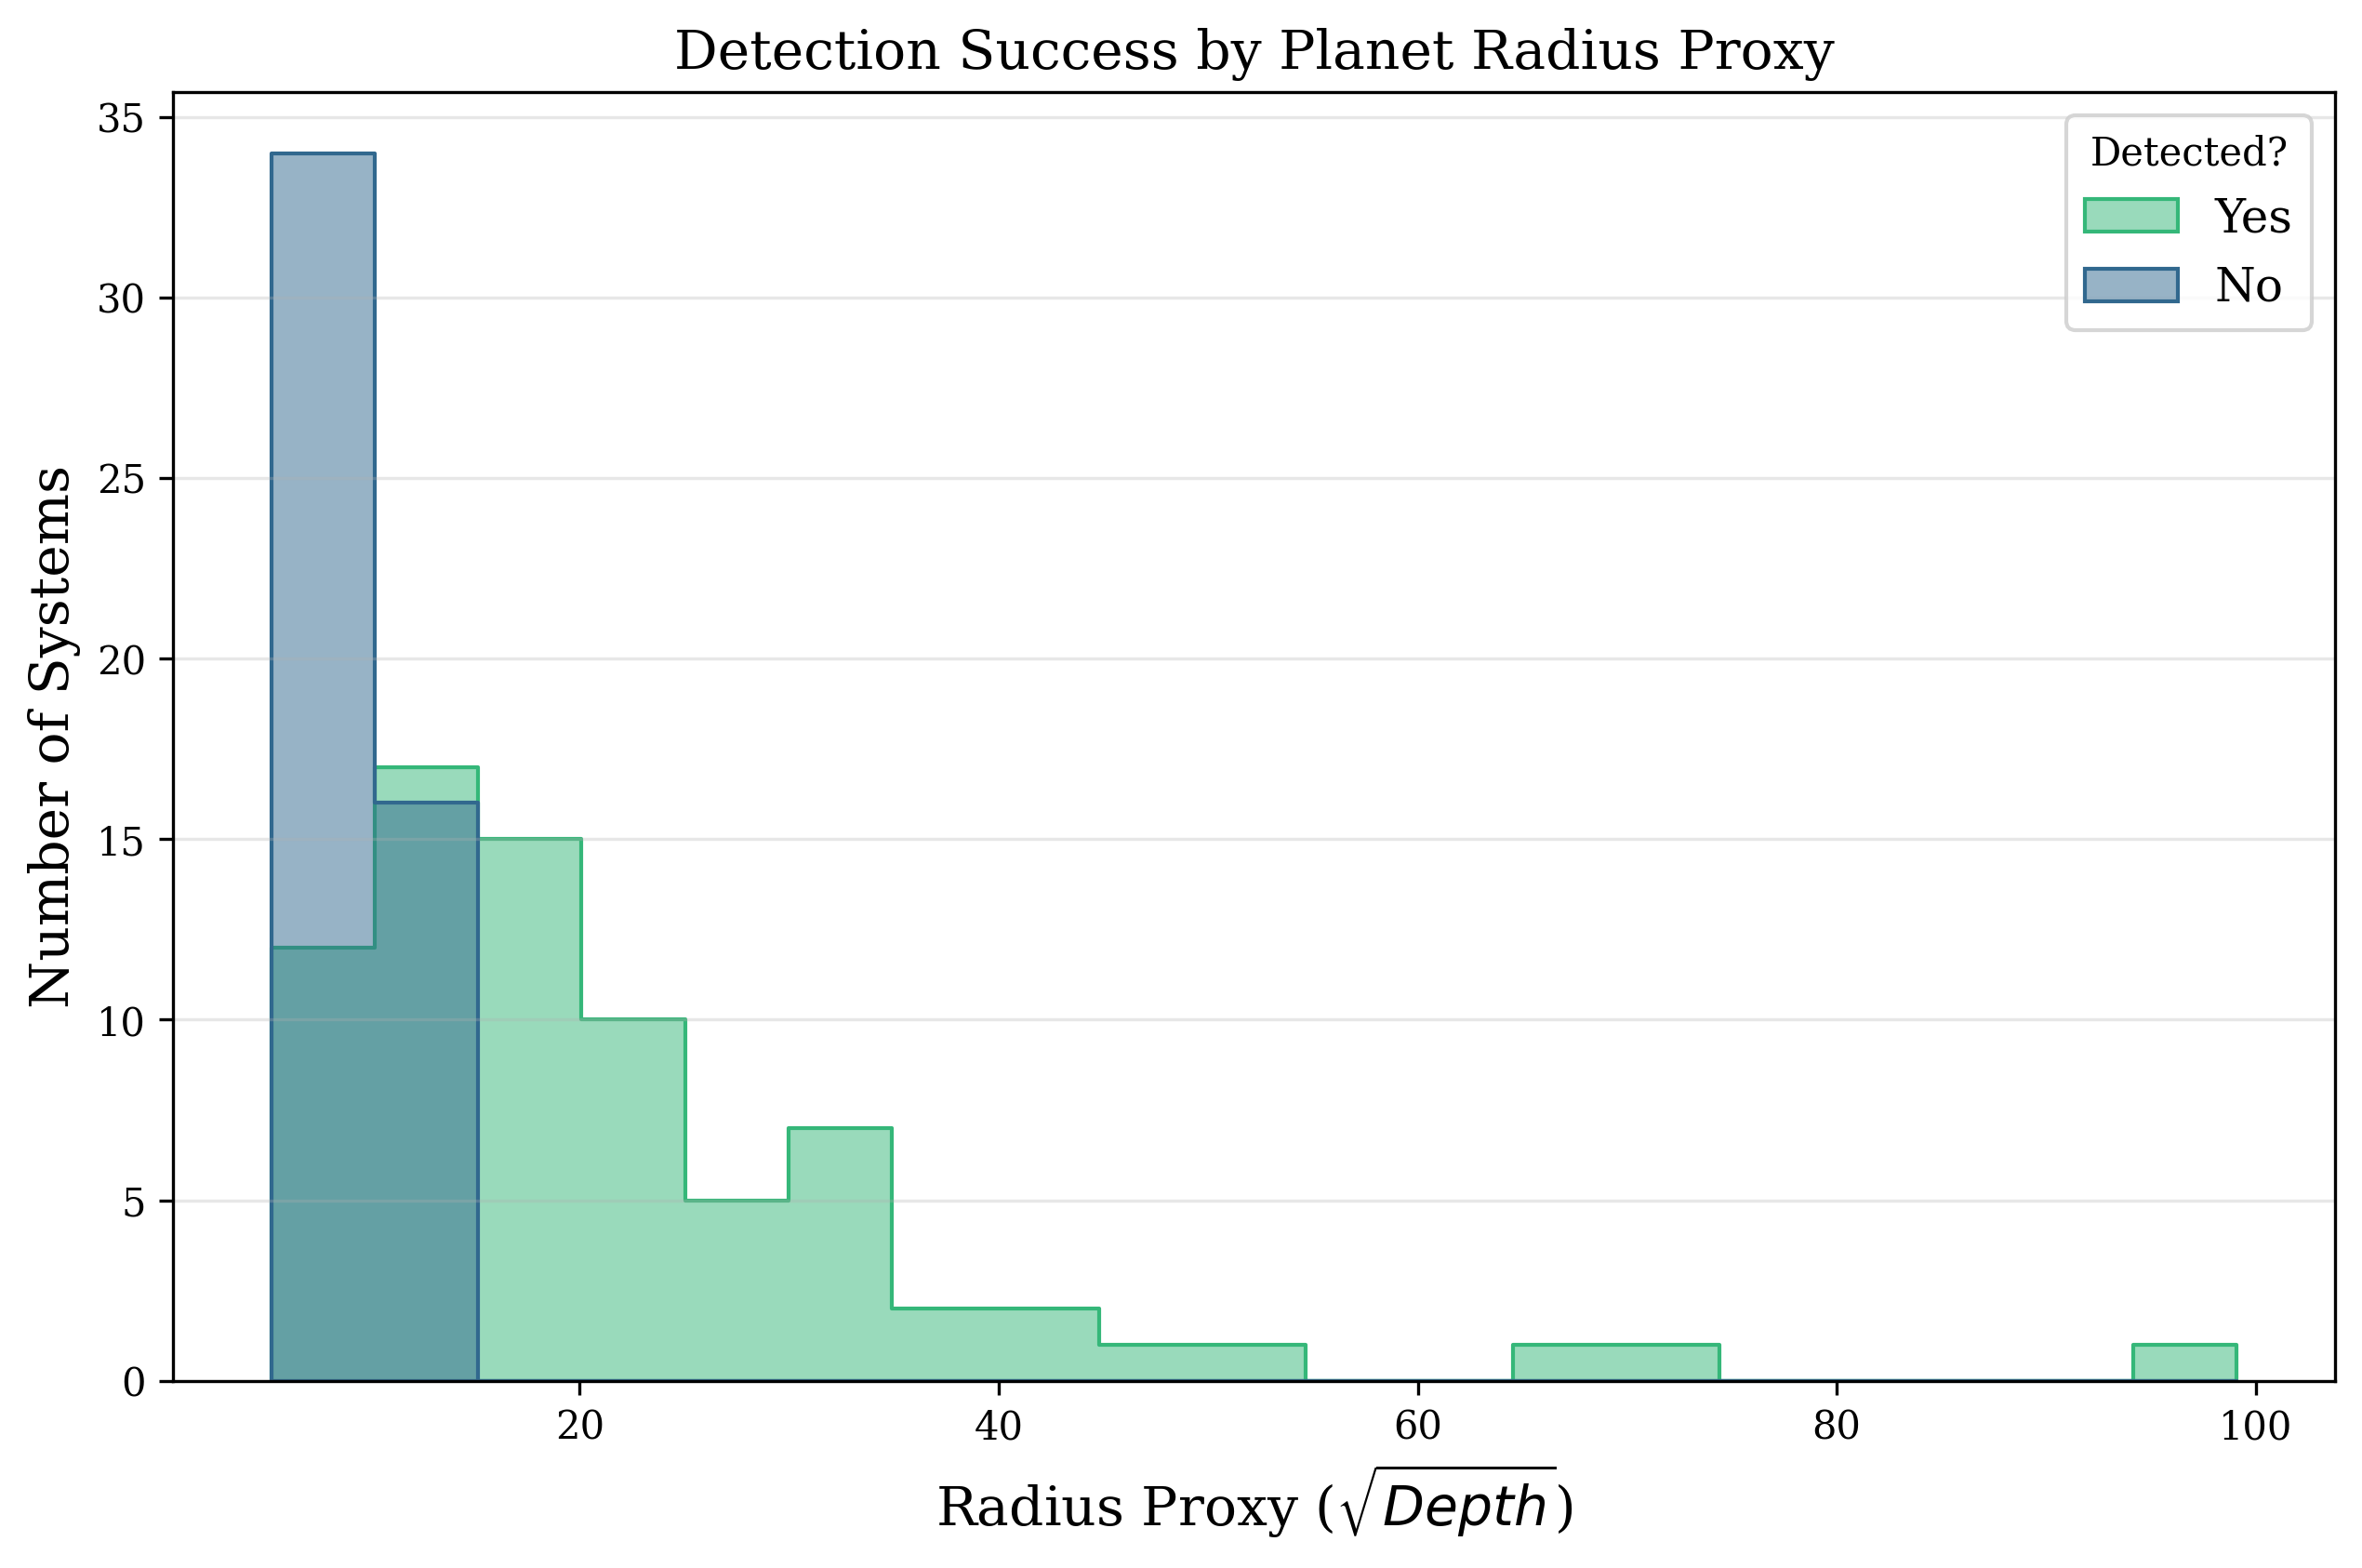

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare the data: Link test results with physical features
analysis_df = results_df.merge(feature_df[['system_id', 'bls_depth_ppm', 'noise_ppm', 'bls_period']], on='system_id')

# Create a proxy for Radius (sqrt of depth)
analysis_df['radius_proxy'] = np.sqrt(analysis_df['bls_depth_ppm'].clip(lower=0))

# 2. Plot Detection Rate vs Radius Proxy
plt.figure(figsize=(10, 6))

# Define bins for the radius proxy
bins = np.linspace(analysis_df['radius_proxy'].min(), analysis_df['radius_proxy'].max(), 20)

# Plot the distribution of all true transits
sns.histplot(data=analysis_df[analysis_df['true_has_transit'] == 1], 
             x='radius_proxy', hue='pred_has_transit', 
             element='step', palette='viridis', bins=bins, alpha=0.5)

plt.title("Detection Success by Planet Radius Proxy")
plt.xlabel("Radius Proxy ($\sqrt{Depth}$)")
plt.ylabel("Number of Systems")
plt.legend(title="Detected?", labels=["Yes", "No"])
plt.grid(axis='y', alpha=0.3)
plt.show()

/var/folders/dt/hdl85s4s5jng99gtl5y_bxnr0000gn/T/ipykernel_3337/1210978753.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")


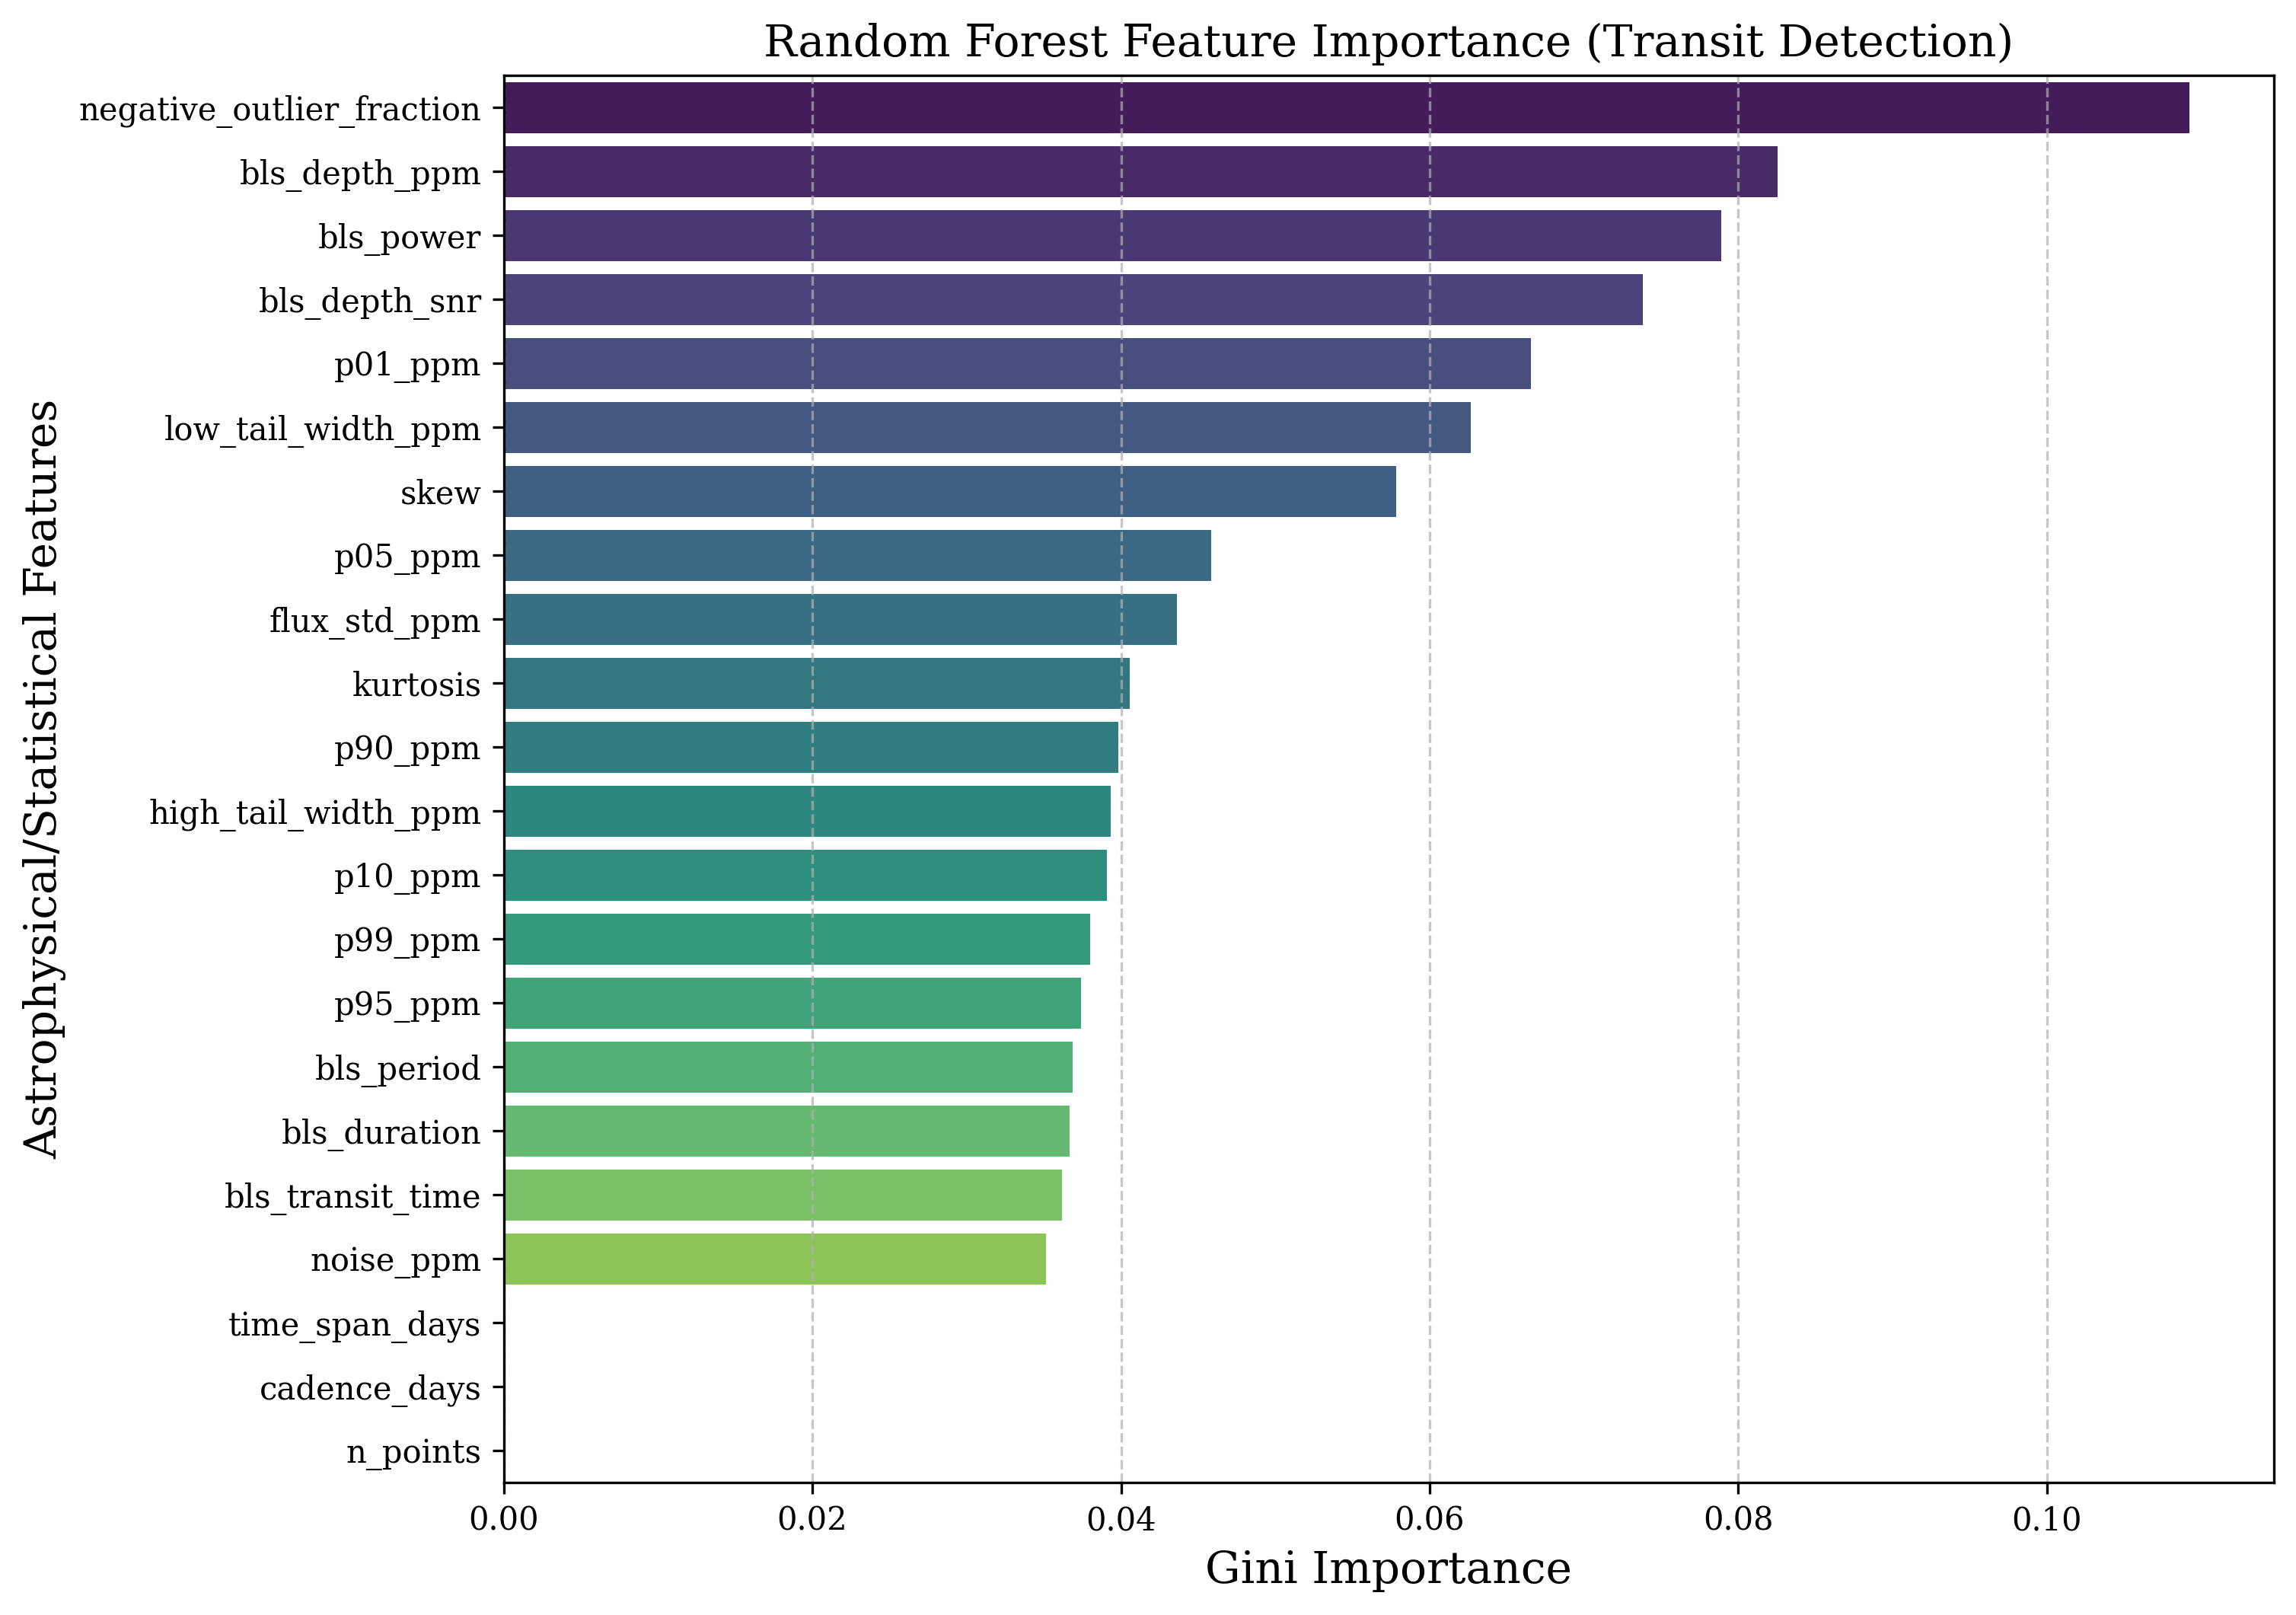

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the importance from the 'model' step of your pipeline
importances = transit_clf.named_steps["model"].feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")
plt.title("Random Forest Feature Importance (Transit Detection)")
plt.xlabel("Gini Importance")
plt.ylabel("Astrophysical/Statistical Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

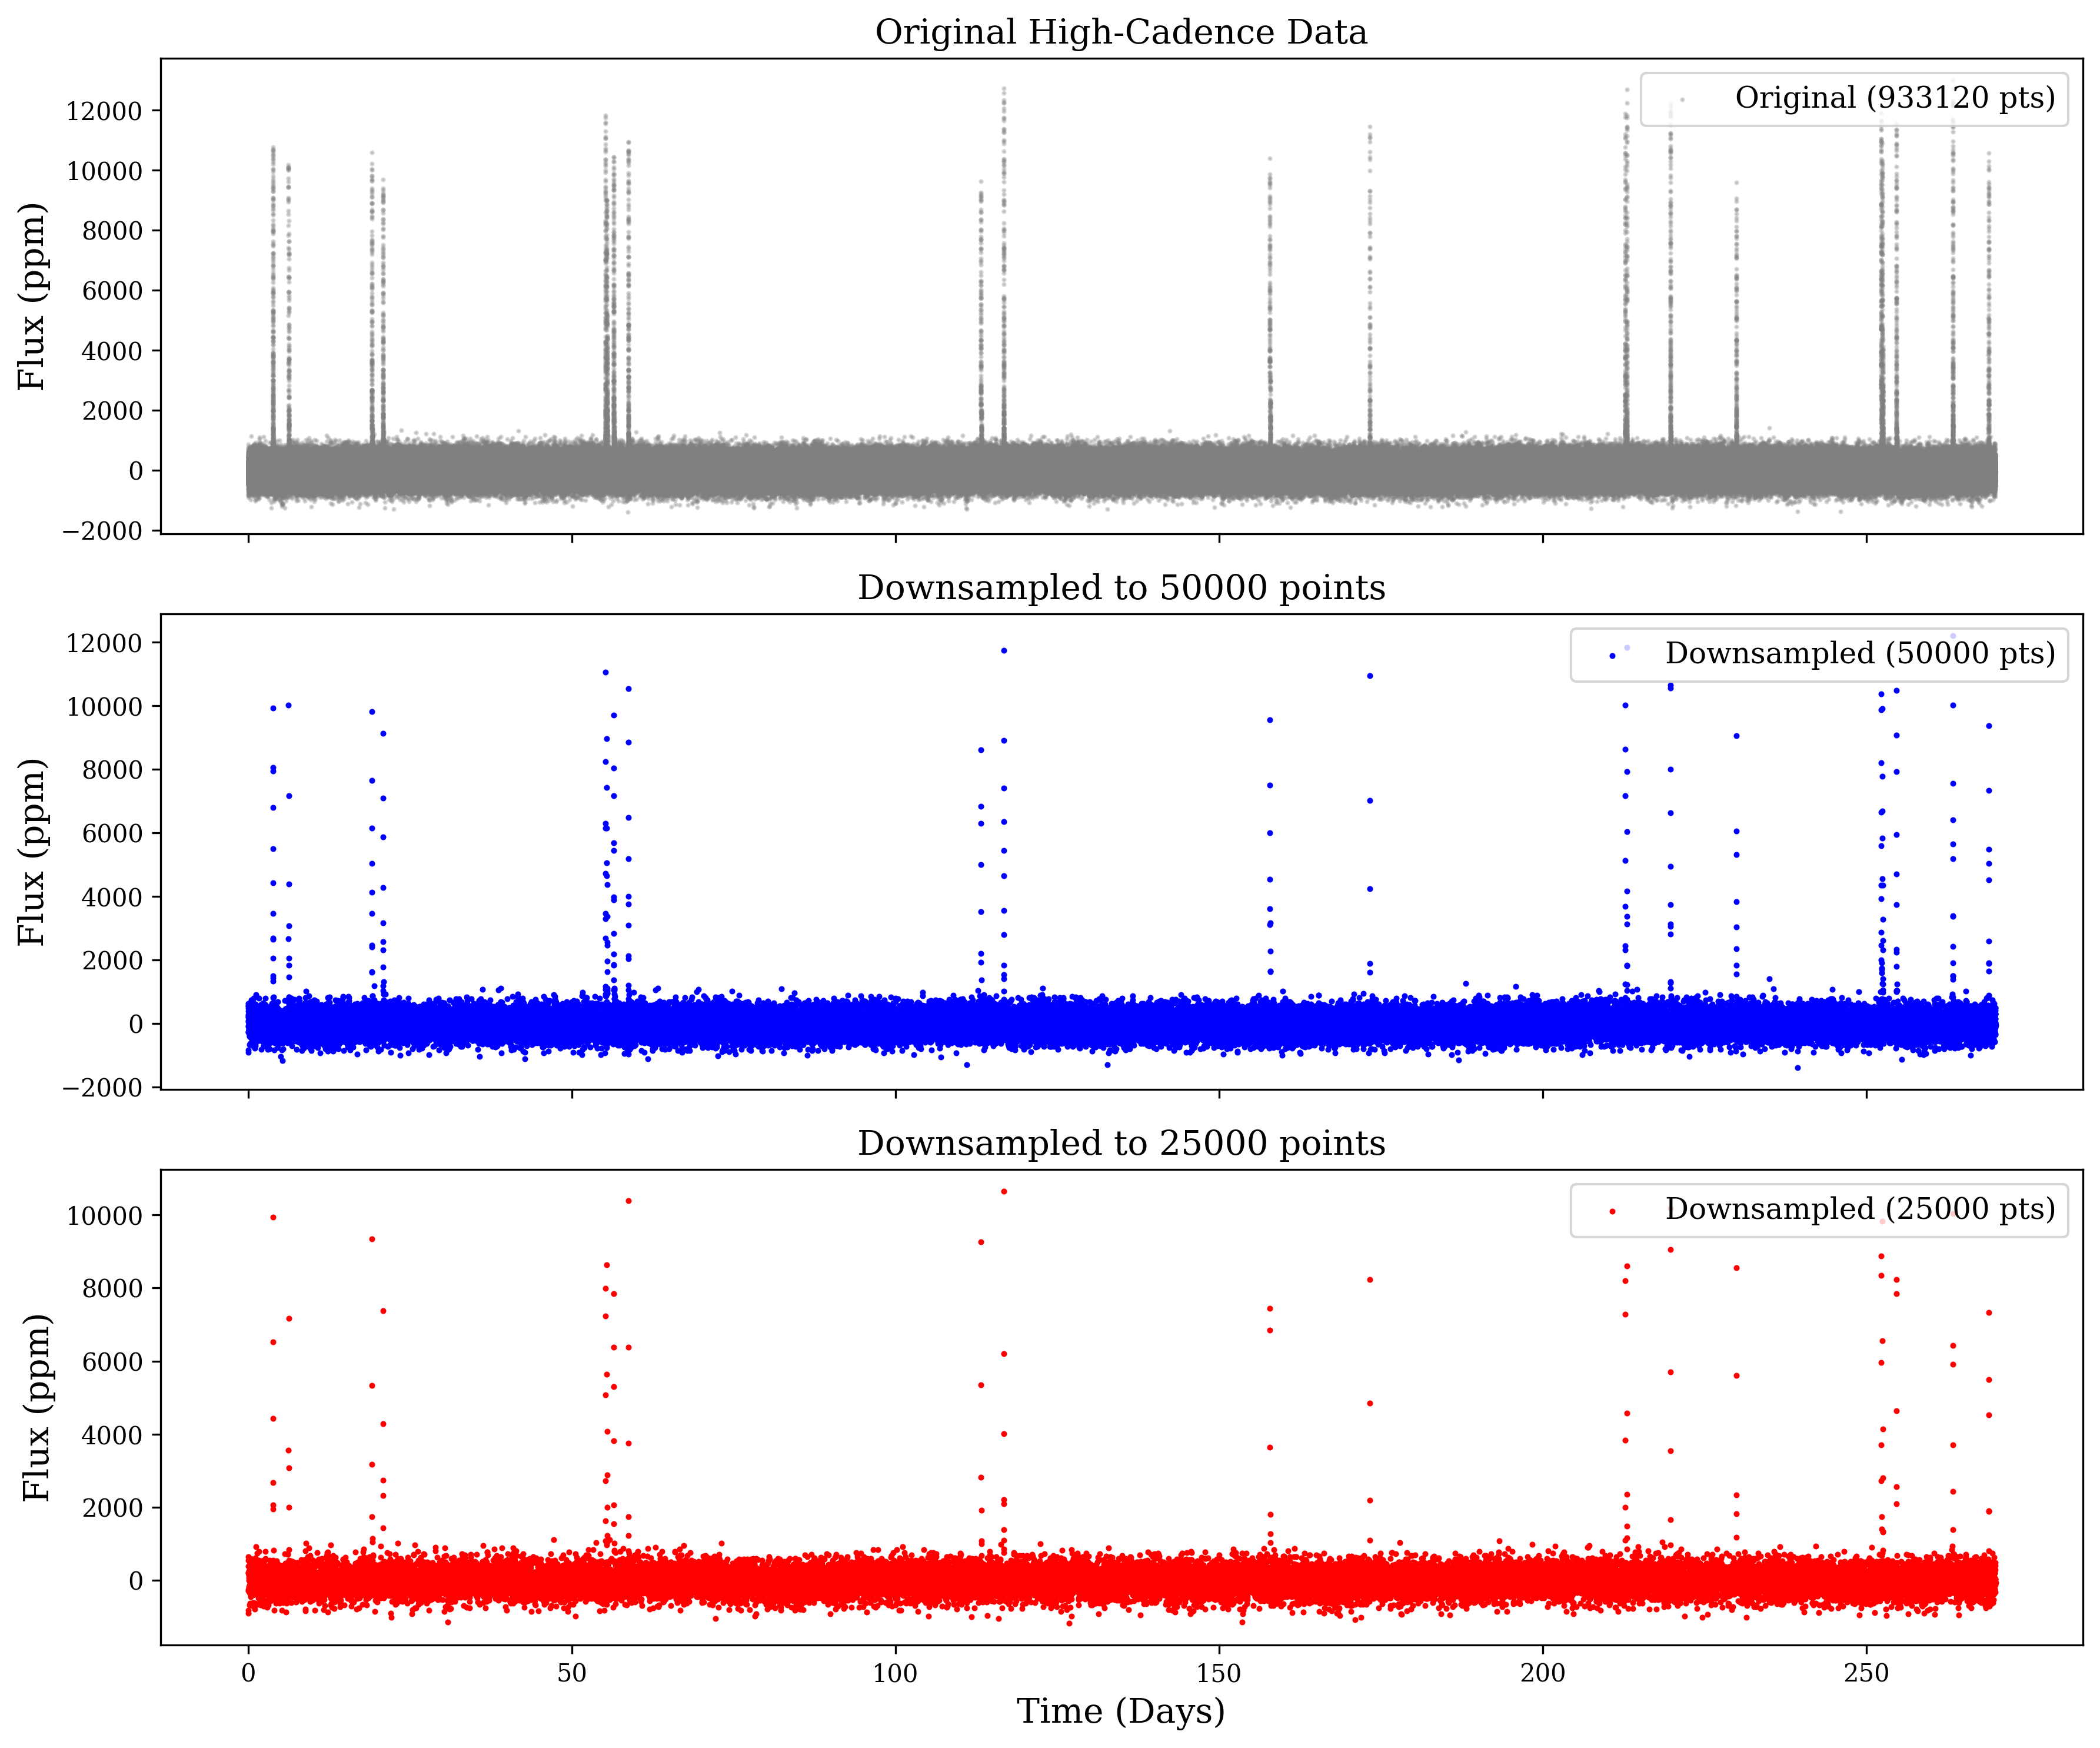

In [39]:
import matplotlib.pyplot as plt

def verify_downsampling(time, flux, target_points=[50_000, 25_000]):
    """Compare raw ppm light curve with downsampled versions."""
    fig, axes = plt.subplots(len(target_points) + 1, 1, figsize=(12, 10), sharex=True)
    
    # 1. Original Data
    t_raw, y_raw = lightcurve_to_ppm(time, flux, max_points=None)
    axes[0].scatter(t_raw, y_raw, s=1, color='gray', alpha=0.3, label=f"Original ({len(t_raw)} pts)")
    axes[0].set_title("Original High-Cadence Data")
    
    # 2. Downsampled Versions
    colors = ['blue', 'red']
    for i, pts in enumerate(target_points):
        t_down, y_down = lightcurve_to_ppm(time, flux, max_points=pts)
        axes[i+1].scatter(t_down, y_down, s=2, color=colors[i], label=f"Downsampled ({len(t_down)} pts)")
        axes[i+1].set_title(f"Downsampled to {pts} points")
    
    for ax in axes:
        ax.legend(loc='upper right')
        ax.set_ylabel("Flux (ppm)")
    
    plt.xlabel("Time (Days)")
    plt.tight_layout()
    plt.show()

# Run the check on your test system
time, flux = load_classifier_lightcurve(f"outputs/{df['system_id'].iloc[13]}/")
verify_downsampling(time, flux)

## Multiclass Event Classifier: Neither, Flare, Transit, or Both

This model uses the same light-curve feature workflow as the binary transit classifier, but trains on all four event classes: `neither`, `flare`, `transit`, and `both`. The output includes class probabilities plus confidence diagnostics so ambiguous systems can be inspected instead of treated as hard labels.


In [ ]:
def extract_flare_features(time, flux, max_points=6_000):
    """Positive-tail and burst-shape features useful for flare classification."""
    t_days, y_ppm = lightcurve_to_ppm(time, flux, max_points=max_points)
    sigma = robust_noise_ppm(y_ppm)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = max(float(np.nanstd(y_ppm)), 1.0)

    positive = np.clip(y_ppm, 0.0, None)
    above_3 = y_ppm > 3.0 * sigma
    above_5 = y_ppm > 5.0 * sigma

    if len(t_days) > 1:
        cadence = float(np.nanmedian(np.diff(t_days)))
    else:
        cadence = np.nan

    # Longest contiguous positive excursion above 3 sigma, in points and days.
    longest_run = 0
    current_run = 0
    for is_high in above_3:
        if is_high:
            current_run += 1
            longest_run = max(longest_run, current_run)
        else:
            current_run = 0

    max_idx = int(np.nanargmax(y_ppm)) if len(y_ppm) else 0
    local_start = max(0, max_idx - 20)
    local_stop = min(len(y_ppm), max_idx + 21)
    local_window = y_ppm[local_start:local_stop]

    return {
        "flare_max_ppm": float(np.nanmax(y_ppm)),
        "flare_max_snr": float(np.nanmax(y_ppm) / sigma),
        "flare_p99_snr": float(np.nanpercentile(y_ppm, 99) / sigma),
        "flare_positive_area_ppm_day": float(np.nansum(positive) * cadence) if np.isfinite(cadence) else np.nan,
        "flare_positive_fraction_3sigma": float(np.mean(above_3)),
        "flare_positive_fraction_5sigma": float(np.mean(above_5)),
        "flare_longest_run_3sigma": float(longest_run),
        "flare_longest_duration_3sigma_days": float(longest_run * cadence) if np.isfinite(cadence) else np.nan,
        "flare_peak_local_contrast": float(np.nanmax(local_window) - np.nanmedian(local_window)) if len(local_window) else np.nan,
    }

def build_event_feature_table(labels_df, max_systems=None, max_points=6_000):
    """Build features and 4-class labels: neither, flare, transit, both."""
    event_labels = {
        0: "neither",
        1: "flare",
        2: "transit",
        3: "both",
    }
    source_df = labels_df[labels_df["anomaly_class"].isin(event_labels)].copy()
    if max_systems is not None:
        source_df = source_df.head(max_systems)

    rows = []
    for _, row in tqdm(source_df.iterrows(), total=len(source_df), desc="Extracting event features"):
        system_id = row["system_id"]
        time, flux = load_classifier_lightcurve(f"outputs/{system_id}/")
        if time is None:
            continue

        try:
            features = extract_transit_classifier_features(time, flux, max_points=max_points)
            features.update(extract_flare_features(time, flux, max_points=max_points))
        except Exception as exc:
            print(f"Skipping {system_id}: {exc}")
            continue

        features.update({
            "system_id": system_id,
            "event_class": event_labels[int(row["anomaly_class"])],
            "anomaly_class": int(row["anomaly_class"]),
        })
        rows.append(features)

    return pd.DataFrame(rows)

def add_confidence_columns(prediction_df, class_names):
    """Add max probability, probability margin, and normalized entropy confidence diagnostics."""
    prob_cols = [f"p_{name}" for name in class_names]
    probs = prediction_df[prob_cols].to_numpy(dtype=float)
    sorted_probs = np.sort(probs, axis=1)
    top = sorted_probs[:, -1]
    second = sorted_probs[:, -2] if probs.shape[1] > 1 else np.zeros_like(top)
    entropy = -np.sum(np.clip(probs, 1e-12, 1.0) * np.log(np.clip(probs, 1e-12, 1.0)), axis=1)
    max_entropy = np.log(probs.shape[1])

    prediction_df["confidence"] = top
    prediction_df["confidence_margin"] = top - second
    prediction_df["confidence_entropy"] = 1.0 - entropy / max_entropy
    return prediction_df

In [ ]:
# Build the 4-class event table and train the neither/flare/transit/both classifier.
# For faster iteration, set max_systems to a smaller value; None uses all systems.
event_feature_df = build_event_feature_table(df, max_systems=None, max_points=50_000)
print(event_feature_df.shape)
print(event_feature_df["event_class"].value_counts())
display(event_feature_df.head())

event_feature_cols = [
    col for col in event_feature_df.columns
    if col not in {"system_id", "event_class", "anomaly_class"}
]
X_event = event_feature_df[event_feature_cols]
y_event = event_feature_df["event_class"]

X_event_train, X_event_test, y_event_train, y_event_test, event_ids_train, event_ids_test = train_test_split(
    X_event,
    y_event,
    event_feature_df["system_id"],
    test_size=0.25,
    random_state=42,
    stratify=y_event,
)

event_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

event_clf.fit(X_event_train, y_event_train)
event_classes = list(event_clf.named_steps["model"].classes_)
event_proba = event_clf.predict_proba(X_event_test)
event_pred = event_clf.predict(X_event_test)

print("Confusion matrix rows=true, columns=predicted")
print(pd.DataFrame(
    confusion_matrix(y_event_test, event_pred, labels=event_classes),
    index=[f"true_{name}" for name in event_classes],
    columns=[f"pred_{name}" for name in event_classes],
))
print("\nClassification report")
print(classification_report(y_event_test, event_pred, labels=event_classes))

probability_df = pd.DataFrame(
    event_proba,
    columns=[f"p_{name}" for name in event_classes],
)

event_results_df = pd.concat([
    pd.DataFrame({
        "system_id": event_ids_test.values,
        "true_event_class": y_event_test.values,
        "pred_event_class": event_pred,
    }).reset_index(drop=True),
    probability_df.reset_index(drop=True),
], axis=1)
event_results_df = add_confidence_columns(event_results_df, event_classes)
event_results_df = event_results_df.sort_values("confidence", ascending=False)

display(event_results_df.head(20))
display(event_results_df.sort_values("confidence").head(20))


Extracting event features:   0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 25)
event_class
transit    250
neither    250
flare      250
both       250
Name: count, dtype: int64


,flux_std_ppm,skew,p01_ppm,p05_ppm,p95_ppm,p99_ppm,negative_outlier_fraction,bls_power,bls_period,bls_duration,...,flare_p99_snr,flare_positive_area_ppm_day,flare_positive_fraction_3sigma,flare_positive_fraction_5sigma,flare_longest_run_3sigma,flare_longest_duration_3sigma_days,flare_peak_local_contrast,system_id,event_class,anomaly_class
0,295.584315,-0.001836,-686.391822,-490.817329,483.842996,679.226866,0.00120,6.187374,72.625729,0.32,...,2.318389,32193.969264,0.00122,0.00000,1.0,0.005498,1204.040232,sys_0000,transit,2
1,293.952245,-0.002489,-683.510722,-483.843204,483.724310,679.389668,0.00164,6.076012,92.884653,0.32,...,2.339107,32151.871423,0.00154,0.00000,1.0,0.005498,1111.364728,sys_0001,neither,0
2,347.014442,2.804303,-680.723006,-480.505167,498.995082,762.821030,0.00136,6.990698,4.504498,0.32,...,2.605260,35309.693200,0.00624,0.00332,8.0,0.043981,5431.495347,sys_0002,flare,1
3,298.036559,0.032535,-686.719463,-487.541559,490.923380,702.937482,0.00164,6.788566,72.625729,0.64,...,2.420458,32891.098817,0.00232,0.00000,3.0,0.016493,1031.747880,sys_0003,flare,1
4,548.157821,7.143635,-693.311858,-492.841247,535.682734,1629.547493,0.00140,20.694242,3.038651,0.64,...,5.583633,44570.812554,0.01568,0.01070,56.0,0.307870,7571.241058,sys_0004,flare,1


Confusion matrix rows=true, columns=predicted
              pred_both  pred_flare  pred_neither  pred_transit
true_both            42          19             1             1
true_flare           13          43             4             2
true_neither          1           0            59             3
true_transit          0           0            22            40

Classification report
              precision    recall  f1-score   support

        both       0.75      0.67      0.71        63
       flare       0.69      0.69      0.69        62
     neither       0.69      0.94      0.79        63
     transit       0.87      0.65      0.74        62

    accuracy                           0.74       250
   macro avg       0.75      0.74      0.73       250
weighted avg       0.75      0.74      0.73       250



,system_id,true_event_class,pred_event_class,p_both,p_flare,p_neither,p_transit,confidence,confidence_margin,confidence_entropy
32,sys_0440,transit,transit,0.000000,0.000000,0.001336,0.998664,0.998664,0.997329,0.992660
206,sys_0609,transit,transit,0.001505,0.000000,0.000000,0.998495,0.998495,0.996991,0.991861
125,sys_0453,transit,transit,0.001505,0.000000,0.000000,0.998495,0.998495,0.996991,0.991861
116,sys_0854,both,both,0.998005,0.001995,0.000000,0.000000,0.998005,0.996009,0.989614
248,sys_0218,both,both,0.997672,0.002328,0.000000,0.000000,0.997672,0.995343,0.988140
158,sys_0927,transit,transit,0.002338,0.000000,0.000000,0.997662,0.997662,0.995323,0.988096
123,sys_0190,transit,transit,0.001672,0.000667,0.001003,0.996659,0.996659,0.994987,0.981373
22,sys_0687,both,both,0.995672,0.004328,0.000000,0.000000,0.995672,0.991343,0.979892
38,sys_0118,transit,transit,0.003505,0.000000,0.001003,0.995493,0.995493,0.991988,0.977469
222,sys_0466,both,both,0.994350,0.005650,0.000000,0.000000,0.994350,0.988701,0.974841


,system_id,true_event_class,pred_event_class,p_both,p_flare,p_neither,p_transit,confidence,confidence_margin,confidence_entropy
219,sys_0454,flare,transit,0.247754,0.206990,0.250281,0.294974,0.294974,0.044693,0.005601
242,sys_0857,both,neither,0.165870,0.255277,0.307599,0.271254,0.307599,0.036345,0.016730
231,sys_0027,flare,neither,0.208292,0.248489,0.309473,0.233746,0.309473,0.060984,0.007796
120,sys_0869,both,flare,0.217619,0.316203,0.262444,0.203734,0.316203,0.053760,0.010930
215,sys_0197,both,both,0.320701,0.320606,0.308229,0.050465,0.320701,0.000095,0.103445
86,sys_0824,flare,neither,0.147323,0.270581,0.416927,0.165169,0.416927,0.146347,0.063675
21,sys_0104,neither,both,0.440472,0.183295,0.158009,0.218223,0.440472,0.222249,0.065230
108,sys_0797,flare,neither,0.147162,0.098906,0.452892,0.301039,0.452892,0.151853,0.112049
53,sys_0434,flare,neither,0.176277,0.154850,0.457738,0.211134,0.457738,0.246604,0.076042
228,sys_0621,flare,flare,0.476653,0.486280,0.015521,0.021547,0.486280,0.009627,0.386050


In [2]:
# Merge the test set predictions with the original physical parameters dataframe
full_analysis = pd.merge(
    event_results_df,
    df,  # This is your original dataframe containing 'transit_radius_earth', 'drift', etc.
    on="system_id",
    how="inner"
)

# Optional: verify it looks correct before plotting
display(full_analysis[['system_id', 'true_event_class', 'pred_event_class', 'transit_radius_earth']].head())

NameError: name 'pd' is not defined

In [1]:
def plot_detection_probability(df_analysis, feature_col, label, bins=10):
    # Filter only for systems that actually HAVE a transit
    transit_systems = df_analysis[df_analysis['true_event_class'].isin(['transit', 'both'])].copy()
    
    # A "detection" is when the model correctly identifies a transit component
    transit_systems['is_detected'] = transit_systems['pred_event_class'].isin(['transit', 'both']).astype(int)
    
    # Create bins
    transit_systems['bin'] = pd.cut(transit_systems[feature_col], bins=bins)
    
    # Calculate P(detection) per bin
    bin_stats = transit_systems.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1)

    print(bin_stats[['prob', 'count']])
    
    plt.title(f"P(Detection) vs. {label}")
    plt.xlabel(label)
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# Run for Planet Radius
plot_detection_probability(full_analysis, 'transit_radius_earth', "Planet Radius ($R_{Earth}$)", bins=20)

NameError: name 'full_analysis' is not defined

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Flare Detection Statistics by Bin:
                        efficiency  count
amp_bin                                  
(503.281, 703.345]        0.500000     10
(703.345, 982.939]        0.846154     13
(982.939, 1373.676]       1.000000     18
(1373.676, 1919.74]       1.000000     14
(1919.74, 2682.876]       1.000000      7
(2682.876, 3749.372]      1.000000     12
(3749.372, 5239.823]      1.000000      9
(5239.823, 7322.757]      1.000000     13
(7322.757, 10233.699]     1.000000      8
(10233.699, 14301.799]    1.000000     13
(14301.799, 19987.05]     1.000000      7


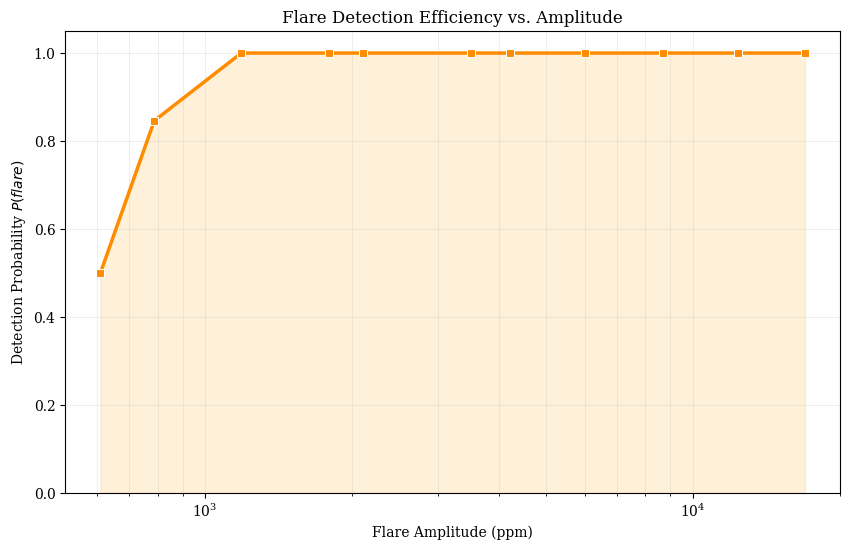

In [47]:
def plot_flare_detection_efficiency(df_analysis, bins=12):
    # 1. Filter for systems that actually HAVE a flare (Flare or Both)
    flare_systems = df_analysis[df_analysis['true_event_class'].isin(['flare', 'both'])].copy()
    
    # 2. A detection is when the model correctly identifies a flare component
    # We ignore the transit part for this specific analysis.
    flare_systems['flare_detected'] = flare_systems['pred_event_class'].isin(['flare', 'both']).astype(int)
    
    # 3. Create log-spaced bins for amplitude to handle the wide dynamic range
    # Ensure amplitude is > 0 for log spacing
    min_amp = flare_systems['flare_amplitude'].replace(0, np.nan).min()
    max_amp = flare_systems['flare_amplitude'].max()
    
    log_bins = np.logspace(np.log10(min_amp), np.log10(max_amp), bins)
    flare_systems['amp_bin'] = pd.cut(flare_systems['flare_amplitude'], bins=log_bins)
    
    # 4. Calculate P(detection) per bin
    stats = flare_systems.groupby('amp_bin', observed=True).agg(
        efficiency=('flare_detected', 'mean'),
        midpoint=('flare_amplitude', 'median'),
        count=('flare_detected', 'count')
    )

    # 5. Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stats, x='midpoint', y='efficiency', marker='s', color='darkorange', linewidth=2.5)
    plt.fill_between(stats['midpoint'], 0, stats['efficiency'], color='orange', alpha=0.15)
    
    plt.xscale('log')
    plt.title("Flare Detection Efficiency vs. Amplitude")
    plt.xlabel("Flare Amplitude (ppm)")
    plt.ylabel("Detection Probability $P(flare)$")
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    print("Flare Detection Statistics by Bin:")
    print(stats[['efficiency', 'count']])
    
    plt.show()

# Run the analysis on your test set results
plot_flare_detection_efficiency(full_analysis)

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1. Re-calculate your custom predictions based on a 0.4 transit threshold
transit_indices = [i for i, c in enumerate(event_classes) if c in ['transit', 'both']]
custom_preds = []

for probs in event_proba:
    # Combine probability of any transit component existing
    p_transit_total = sum(probs[i] for i in transit_indices)
    
    if p_transit_total >= 0.4:
        # If we suspect a transit, pick between 'both' and 'transit'
        p_both = probs[event_classes.index('both')]
        p_transit_only = probs[event_classes.index('transit')]
        custom_preds.append('both' if p_both > p_transit_only else 'transit')
    else:
        # Otherwise, stick to the standard winner (likely 'neither' or 'flare')
        custom_preds.append(event_classes[np.argmax(probs)])


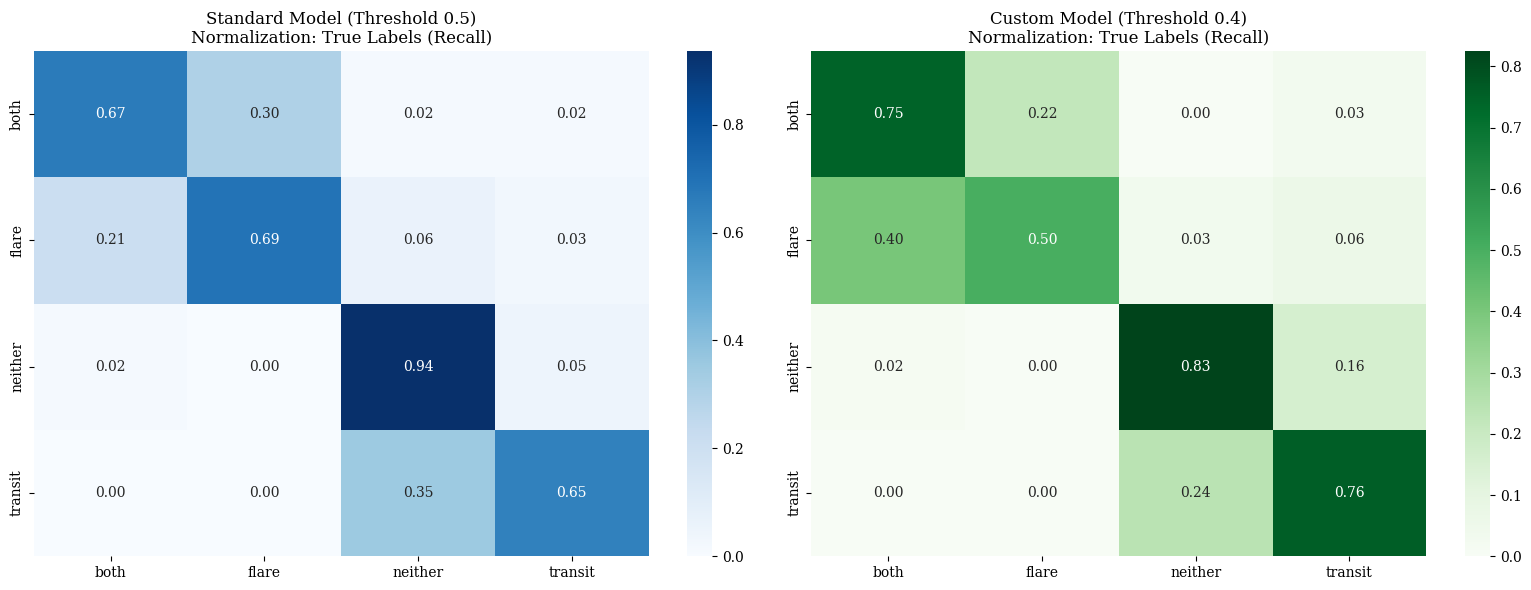

,Class,Precision Delta,Recall Delta,F1 Delta
0,both,-0.106164,0.079365,-0.014706
1,flare,-0.004659,-0.193548,-0.114109
2,neither,0.067577,-0.111111,-0.004068
3,transit,-0.123533,0.112903,0.011259


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_full_threshold_impact(y_true, y_orig, y_custom, classes):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Generate Confusion Matrices
    cm_orig = confusion_matrix(y_true, y_orig, labels=classes, normalize='true')
    cm_cust = confusion_matrix(y_true, y_custom, labels=classes, normalize='true')
    
    # Plot Original
    sns.heatmap(cm_orig, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes, ax=axes[0], cmap='Blues')
    axes[0].set_title("Standard Model (Threshold 0.5)\nNormalization: True Labels (Recall)")
    
    # Plot Custom
    sns.heatmap(cm_cust, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes, ax=axes[1], cmap='Greens')
    axes[1].set_title("Custom Model (Threshold 0.4)\nNormalization: True Labels (Recall)")
    
    plt.tight_layout()
    plt.show()

    # Per-Class Delta Table
    report_orig = classification_report(y_true, y_orig, output_dict=True)
    report_cust = classification_report(y_true, y_custom, output_dict=True)
    
    stats = []
    for cls in classes:
        stats.append({
            "Class": cls,
            "Precision Delta": report_cust[cls]['precision'] - report_orig[cls]['precision'],
            "Recall Delta": report_cust[cls]['recall'] - report_orig[cls]['recall'],
            "F1 Delta": report_cust[cls]['f1-score'] - report_orig[cls]['f1-score']
        })
    
    return pd.DataFrame(stats)

# Run the full analysis
delta_df = analyze_full_threshold_impact(y_event_test, event_pred, custom_preds, event_classes)
display(delta_df)